# Category-level FEA patterns and FACS-related group summaries

This notebook characterizes how the 63 dynamic Facial Expression Activation (FEA) channels vary across the seven EmoHeVRDB expression categories and then summarizes semantically related FEA channels into FACS-related groups.

It builds directly on the decisions documented in `03_characterize_fea_channels.ipynb`:

- **Sequence mean** is the primary reenactment-level summary.
- **Sequence P90** is a sensitivity summary for stronger or more episodic activation.
- **Sample-weighted category profiles** are the primary description of the recorded dataset.
- **Participant-balanced profiles** are a robustness check that gives each participant equal weight within a category.
- **Participant-specific neutral centering** is a separate sensitivity analysis.
- Raw Meta coefficients are always retained; channel-wise standardized views are used only to compare relative category-associated patterns across channels.

The analyses in this notebook are **descriptive**. They characterize FEA patterns associated with expression categories. They do not measure model reliance, validate the Meta Face Tracking API against manual FACS coding, or convert Meta coefficients into validated Action Unit measurements.

Outputs are written to:

`outputs/04_category_fea_patterns/`


## 1. Imports and paths

Run this notebook from:

`emohevrdb-dfer/6_discussion/fea_analysis/`

The notebook expects the canonical DFEA CSV files created by `create_canonical_fea_analysis_datasets.ipynb`. It also requires the semantic FEA-to-FACS mapping JSON created for this analysis workflow.


In [1]:
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

ANALYSIS_DIR = Path.cwd()
OUTPUT_DIR = ANALYSIS_DIR / "outputs" / "04_category_fea_patterns"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR = ANALYSIS_DIR / "data"
MAPPING_PATH = DATA_DIR / "facs_fea_mapping.json"

print("Data directory:", DATA_DIR.resolve())
print("Mapping:", MAPPING_PATH.resolve())
print("Output directory:", OUTPUT_DIR.resolve())


Data directory: /workspace/repos/emohevrdb-dfer/6_discussion/fea_analysis/data
Mapping: /workspace/repos/emohevrdb-dfer/6_discussion/fea_analysis/data/facs_fea_mapping.json
Output directory: /workspace/repos/emohevrdb-dfer/6_discussion/fea_analysis/outputs/04_category_fea_patterns


## 2. Canonical schema and analysis constants


In [2]:
CATEGORY_ORDER = [
    "Anger",
    "Disgust",
    "Fear",
    "Happiness",
    "Neutral",
    "Sadness",
    "Surprise",
]

SPLITS = ["train", "validation", "test"]

META_COLUMNS = [
    "reenactment_id",
    "split",
    "sequence_timestamp",
    "set_id",
    "participant_id",
    "level_id",
    "emoji_id",
    "timestep",
    "observation_timestamp",
    "is_reference_observation",
    "true_label_id",
    "true_label",
]

FEA_COLUMNS = [
    "BrowLowererL",
    "BrowLowererR",
    "CheekPuffL",
    "CheekPuffR",
    "CheekRaiserL",
    "CheekRaiserR",
    "CheekSuckL",
    "CheekSuckR",
    "ChinRaiserB",
    "ChinRaiserT",
    "DimplerL",
    "DimplerR",
    "EyesClosedL",
    "EyesClosedR",
    "EyesLookDownL",
    "EyesLookDownR",
    "EyesLookLeftL",
    "EyesLookLeftR",
    "EyesLookRightL",
    "EyesLookRightR",
    "EyesLookUpL",
    "EyesLookUpR",
    "InnerBrowRaiserL",
    "InnerBrowRaiserR",
    "JawDrop",
    "JawSidewaysLeft",
    "JawSidewaysRight",
    "JawThrust",
    "LidTightenerL",
    "LidTightenerR",
    "LipCornerDepressorL",
    "LipCornerDepressorR",
    "LipCornerPullerL",
    "LipCornerPullerR",
    "LipFunnelerLB",
    "LipFunnelerLT",
    "LipFunnelerRB",
    "LipFunnelerRT",
    "LipPressorL",
    "LipPressorR",
    "LipPuckerL",
    "LipPuckerR",
    "LipStretcherL",
    "LipStretcherR",
    "LipSuckLB",
    "LipSuckLT",
    "LipSuckRB",
    "LipSuckRT",
    "LipTightenerL",
    "LipTightenerR",
    "LipsToward",
    "LowerLipDepressorL",
    "LowerLipDepressorR",
    "MouthLeft",
    "MouthRight",
    "NoseWrinklerL",
    "NoseWrinklerR",
    "OuterBrowRaiserL",
    "OuterBrowRaiserR",
    "UpperLidRaiserL",
    "UpperLidRaiserR",
    "UpperLipRaiserL",
    "UpperLipRaiserR",
]

assert len(FEA_COLUMNS) == 63
assert len(FEA_COLUMNS) == len(set(FEA_COLUMNS))


## 3. Load and validate DFEA data and semantic mapping

The mapping is used only as a semantic crosswalk. A group such as `AU12 Lip Corner Puller` means *FEA channels semantically related to AU12*, not a validated AU12 measurement.


In [3]:
dfea = {
    split: pd.read_csv(DATA_DIR / f"dfea_{split}.csv")
    for split in SPLITS
}

for split, df in dfea.items():
    assert df.columns.tolist() == META_COLUMNS + FEA_COLUMNS
    assert df["split"].eq(split).all()
    assert not df.duplicated(["reenactment_id", "timestep"]).any()
    assert df.groupby("reenactment_id").size().eq(30).all()
    assert df[FEA_COLUMNS].notna().all().all()

all_dfea = pd.concat([dfea[s] for s in SPLITS], ignore_index=True)

mapping = json.loads(MAPPING_PATH.read_text(encoding="utf-8"))
mapping_df = pd.DataFrame(mapping["fea_to_facs"])

assert set(mapping_df["fea_name"]) == set(FEA_COLUMNS)
assert mapping_df["fea_name"].is_unique
assert mapping["interpretation"]["official_meta_to_facs_mapping"] is False
assert mapping["interpretation"]["validated_au_measurement"] is False

print(
    f"DFEA: {len(all_dfea):,} observations, "
    f"{all_dfea['reenactment_id'].nunique():,} reenactments, "
    f"{all_dfea['participant_id'].nunique()} participants."
)
print("Mapping version:", mapping["mapping_version"])


DFEA: 51,810 observations, 1,727 reenactments, 36 participants.
Mapping version: 1.2.1


## 4. Aggregate each 30-step sequence to one value per FEA

Two sequence summaries are retained:

- `mean`: primary summary over all 30 observations;
- `p90`: sensitivity summary emphasizing the upper part of the trajectory without depending on a single maximum.

The reenactment remains the natural analysis unit.


In [4]:
REENACTMENT_META = [
    "reenactment_id",
    "split",
    "sequence_timestamp",
    "set_id",
    "participant_id",
    "level_id",
    "emoji_id",
    "true_label_id",
    "true_label",
]

metadata = (
    all_dfea[REENACTMENT_META]
    .drop_duplicates("reenactment_id")
    .set_index("reenactment_id")
    .sort_index()
)

assert metadata.index.is_unique

sequence_mean = (
    all_dfea
    .groupby("reenactment_id", sort=True)[FEA_COLUMNS]
    .mean()
)

sequence_p90 = (
    all_dfea
    .groupby("reenactment_id", sort=True)[FEA_COLUMNS]
    .quantile(0.90)
)

assert sequence_mean.index.equals(metadata.index)
assert sequence_p90.index.equals(metadata.index)

sequence_summaries = {
    "mean": metadata.join(sequence_mean).reset_index(),
    "p90": metadata.join(sequence_p90).reset_index(),
}

for metric, df in sequence_summaries.items():
    assert len(df) == all_dfea["reenactment_id"].nunique()
    assert df["reenactment_id"].is_unique
    assert df[FEA_COLUMNS].notna().all().all()

    export_df = df.copy()
    export_df.to_csv(
        OUTPUT_DIR / f"reenactment_fea_{metric}.csv",
        index=False,
    )

display(sequence_summaries["mean"].head())


,reenactment_id,split,sequence_timestamp,set_id,participant_id,level_id,emoji_id,true_label_id,true_label,BrowLowererL,BrowLowererR,CheekPuffL,CheekPuffR,CheekRaiserL,CheekRaiserR,CheekSuckL,CheekSuckR,ChinRaiserB,ChinRaiserT,DimplerL,DimplerR,EyesClosedL,EyesClosedR,EyesLookDownL,EyesLookDownR,EyesLookLeftL,EyesLookLeftR,EyesLookRightL,EyesLookRightR,EyesLookUpL,EyesLookUpR,InnerBrowRaiserL,InnerBrowRaiserR,JawDrop,JawSidewaysLeft,JawSidewaysRight,JawThrust,LidTightenerL,LidTightenerR,LipCornerDepressorL,LipCornerDepressorR,LipCornerPullerL,LipCornerPullerR,LipFunnelerLB,LipFunnelerLT,LipFunnelerRB,LipFunnelerRT,LipPressorL,LipPressorR,LipPuckerL,LipPuckerR,LipStretcherL,LipStretcherR,LipSuckLB,LipSuckLT,LipSuckRB,LipSuckRT,LipTightenerL,LipTightenerR,LipsToward,LowerLipDepressorL,LowerLipDepressorR,MouthLeft,MouthRight,NoseWrinklerL,NoseWrinklerR,OuterBrowRaiserL,OuterBrowRaiserR,UpperLidRaiserL,UpperLidRaiserR,UpperLipRaiserL,UpperLipRaiserR
0,1700478995850-2-1-1-0-0,test,1700478995850,2,1,1,0,0,Anger,0.223092,0.248558,4.586167e-02,4.713184e-02,0.084597,0.054520,1.401298e-45,1.401298e-45,2.064964e-01,0.172893,4.641351e-17,2.820168e-17,0.002558,3.515584e-02,0.002150,9.445732e-03,0.007196,0.052455,0.040981,0.00000,0.068054,0.067955,0.058446,0.067597,0.027385,5.065468e-02,0.052946,0.016728,0.131511,5.358323e-02,0.027425,0.016100,1.441377e-15,1.328162e-15,2.269037e-03,4.371917e-02,6.914283e-03,4.409795e-02,1.401298e-45,1.401298e-45,0.248465,2.569245e-01,0.008605,0.000818,0.000707,0.022969,0.000197,0.010669,1.350607e-01,1.135734e-01,0.034223,1.333448e-02,6.485995e-03,1.005199e-08,6.979022e-09,2.847375e-03,3.147109e-03,5.161996e-14,0.000106,1.401298e-45,1.401298e-45,0.016626,1.037630e-02
1,1700478998549-2-1-1-1-5,test,1700478998549,2,1,1,1,5,Sadness,0.094480,0.045010,7.577448e-03,6.172956e-03,0.041957,0.014820,1.401298e-45,1.401298e-45,3.888779e-01,0.337994,1.375618e-05,1.160487e-05,0.020020,1.179088e-02,0.049760,4.816843e-02,0.000000,0.044529,0.042060,0.00000,0.000000,0.000000,0.061237,0.065050,0.019430,2.235537e-02,0.019097,0.048600,0.016761,2.119900e-03,0.815554,0.795844,1.999790e-05,1.582965e-05,6.623035e-02,3.724961e-02,6.550301e-02,3.628417e-02,1.401298e-45,1.401298e-45,0.025754,3.523743e-02,0.135971,0.137012,0.001204,0.014062,0.008118,0.004471,6.429307e-02,4.780819e-02,0.021351,8.822252e-04,8.820727e-04,9.391553e-11,7.925856e-21,3.373950e-04,3.818396e-03,3.155241e-05,0.011380,1.401298e-45,1.401298e-45,0.000005,8.405012e-07
2,1700479001137-2-1-1-2-3,test,1700479001137,2,1,1,2,3,Happiness,0.000002,0.000002,2.426571e-11,2.437032e-11,0.158277,0.166209,1.401298e-45,1.401298e-45,3.353203e-15,0.165736,4.787423e-01,4.768158e-01,0.009758,2.030711e-15,0.009543,2.013840e-12,0.053694,0.140010,0.000000,0.00000,0.044733,0.044517,0.021842,0.039871,0.560646,1.256906e-11,0.009557,0.299710,0.110610,1.431558e-10,0.011147,0.015321,3.577676e-01,3.531083e-01,1.035405e-21,1.120500e-16,1.261667e-21,9.591109e-16,1.354821e-09,1.401298e-45,0.001071,4.682246e-13,0.232302,0.263949,0.111002,0.151666,0.076577,0.132607,5.277947e-17,4.105216e-17,0.028743,1.924846e-01,2.041923e-01,6.905036e-23,6.572523e-04,1.487640e-16,1.610015e-14,2.751507e-02,0.046148,1.401298e-45,1.401298e-45,0.621757,6.316559e-01
3,1700479004312-2-1-1-3-0,test,1700479004312,2,1,1,3,0,Anger,0.034080,0.025056,2.083358e-03,2.915102e-03,0.042228,0.017948,1.401298e-45,1.401298e-45,3.486791e-02,0.032642,8.764961e-23,2.265296e-23,0.002803,3.318854e-04,0.000000,0.000000e+00,0.000000,0.000000,0.134256,0.04777,0.195753,0.196614,0.007921,0.004476,0.014463,6.827924e-03,0.007823,0.003463,0.083300,1.041473e-03,0.011231,0.005077,5.314752e-04,5.314752e-04,3.179950e-36,4.306785e-03,3.882534e-36,3.541502e-03,4.872311e-24,2.231409e-04,0.056829,5.272017e-02,0.001963,0.000570,0.074803,0.006587,0.059890,0.003929,3.626626e-02,2.917296e-02,0.022622,3.448193e-20,2.996825e-20,1.966048e-04,7.260990e-04,9.686588e-11,9.686588e-11,7.351665e-10,0.001072,1.401298e-45,1.401298e-45,0.015579,1.178205e-02
4,1700479005401

## 5. Category sample counts and participant coverage

These counts clarify the difference between the primary **sample-weighted** profiles and the **participant-balanced** robustness profiles.


In [5]:
reenactments = sequence_summaries["mean"][REENACTMENT_META].copy()

category_counts = (
    reenactments
    .groupby("true_label", observed=True)
    .agg(
        n_reenactments=("reenactment_id", "nunique"),
        n_participants=("participant_id", "nunique"),
    )
    .reindex(CATEGORY_ORDER)
    .reset_index()
)

participant_category_counts = (
    reenactments
    .groupby(["participant_id", "true_label"], observed=True)
    .size()
    .rename("n_reenactments")
    .reset_index()
)

category_counts.to_csv(
    OUTPUT_DIR / "category_sample_counts.csv",
    index=False,
)
participant_category_counts.to_csv(
    OUTPUT_DIR / "participant_category_sample_counts.csv",
    index=False,
)

display(category_counts)
print(
    "Observed Participant × Category reenactments range:",
    int(participant_category_counts["n_reenactments"].min()),
    "to",
    int(participant_category_counts["n_reenactments"].max()),
)


,true_label,n_reenactments,n_participants
0,Anger,175,36
1,Disgust,211,36
2,Fear,214,35
3,Happiness,300,36
4,Neutral,306,36
5,Sadness,240,35
6,Surprise,281,36


Observed Participant × Category reenactments range: 1 to 10


## 6. Standardization parameters and neutral baselines

The analyses below retain four related representations. They answer different questions and should not be conflated.

### Raw

`raw` contains the original reenactment-level sequence summary on the Meta coefficient scale. For example, for the sequence mean:

$$
x_{r,f} = \frac{1}{30}\sum_{t=1}^{30} x_{r,t,f}
$$

The same logic applies to the P90 sequence summary. Raw values preserve the original coefficient scale and are the primary measurement-scale representation.

### Standardized

For each sequence summary separately, every FEA channel is standardized across the **1,727 reenactment-level summaries**:

$$
z_{r,f} = \frac{x_{r,f} - \mu_f}{\sigma_f}
$$

where $\mu_f$ and $\sigma_f$ are the pooled mean and standard deviation of FEA channel $f$ across all reenactments.

Interpretation:

- `0` = the pooled reenactment-level mean of that FEA;
- `+1` = one pooled standard deviation above that FEA's mean;
- `-1` = one pooled standard deviation below that FEA's mean.

This representation is useful when comparing category-associated patterns across FEA channels with very different raw coefficient ranges.

### Neutral-centered

For each participant and FEA, the participant's average Neutral summary is subtracted from every reenactment:

$$
\Delta_{r,f} = x_{r,f} - \bar{x}_{p,\mathrm{Neutral},f}
$$

where participant $p$ is the participant associated with reenactment $r$.

Interpretation:

- `0` = that participant's own average Neutral level for the FEA;
- positive values = activation above that participant's Neutral baseline;
- negative values = activation below that participant's Neutral baseline.

This is a participant-specific baseline correction. It is separate from participant balancing.

### Neutral-centered standardized

`neutral_centered_standardized` first performs the participant-specific Neutral subtraction and then expresses the resulting difference in units of the **same pooled raw standard deviation** $\sigma_f$ used above:

$$
\Delta^{(\mathrm{SD})}_{r,f}
=
\frac{x_{r,f} - \bar{x}_{p,\mathrm{Neutral},f}}{\sigma_f}
$$

Interpretation:

- `0` = the participant's own Neutral baseline;
- `+1` = one pooled raw standard deviation above that participant's Neutral baseline;
- `-1` = one pooled raw standard deviation below that participant's Neutral baseline.

This is intentionally **not** a second conventional z-score: after Neutral centering, the values are divided by $\sigma_f$ but are not re-centered around a new pooled mean. Its purpose is to make participant-specific Neutral deviations comparable across FEA channels.

In short:

| Representation | Baseline | Scale | Main purpose |
| --- | --- | --- | --- |
| `raw` | none | original Meta coefficient scale | Preserve measurement-scale values |
| `standardized` | pooled FEA mean | pooled FEA SD | Compare relative category patterns across channels |
| `neutral_centered` | participant's Neutral mean | original coefficient units | Examine change from personal Neutral baseline |
| `neutral_centered_standardized` | participant's Neutral mean | pooled FEA SD | Compare personal Neutral-relative changes across channels |


In [6]:
def add_standardized_values(df, features):
    result = df.copy()
    mu = df[features].mean()
    sigma = df[features].std(ddof=1)

    if (sigma <= 0).any():
        zero_variance = sigma.index[sigma <= 0].tolist()
        raise ValueError(f"Cannot standardize zero-variance features: {zero_variance}")

    result[features] = (df[features] - mu) / sigma
    return result, mu, sigma


def add_neutral_centered_values(df, features):
    neutral_baseline = (
        df.loc[df["true_label"] == "Neutral"]
        .groupby("participant_id", observed=True)[features]
        .mean()
    )

    participants = set(df["participant_id"].unique())
    neutral_participants = set(neutral_baseline.index)
    assert participants == neutral_participants, (
        "Every participant must have a Neutral baseline."
    )

    baseline_for_rows = neutral_baseline.loc[df["participant_id"]].reset_index(drop=True)
    result = df.copy()
    result[features] = (
        df[features].reset_index(drop=True)
        - baseline_for_rows[features].reset_index(drop=True)
    )
    return result, neutral_baseline


standardization = {}
neutral_baselines = {}
derived_sequence_summaries = {}

for metric, df in sequence_summaries.items():
    standardized, mu, sigma = add_standardized_values(df, FEA_COLUMNS)
    neutral_centered, neutral_baseline = add_neutral_centered_values(df, FEA_COLUMNS)

    # Express neutral-relative changes in pooled SD units without recentering them.
    neutral_standardized = neutral_centered.copy()
    neutral_standardized[FEA_COLUMNS] = (
        neutral_centered[FEA_COLUMNS] / sigma
    )

    derived_sequence_summaries[(metric, "raw")] = df
    derived_sequence_summaries[(metric, "standardized")] = standardized
    derived_sequence_summaries[(metric, "neutral_centered")] = neutral_centered
    derived_sequence_summaries[(metric, "neutral_centered_standardized")] = neutral_standardized

    standardization[metric] = {"mean": mu, "std": sigma}
    neutral_baselines[metric] = neutral_baseline

print("Prepared raw, standardized, neutral-centered, and neutral-centered standardized sequence summaries.")


Prepared raw, standardized, neutral-centered, and neutral-centered standardized sequence summaries.


## 7. Build sample-weighted and participant-balanced category profiles

**Sample-weighted** profiles average all reenactments of a category directly.

**Participant-balanced** profiles first average within each Participant × Category combination and then average across participants. This prevents participants with more reenactments from having greater influence in the robustness view.


In [7]:
def aggregate_category_profile(df, value_columns, weighting):
    if weighting == "sample_weighted":
        profile = (
            df
            .groupby("true_label", observed=True)[value_columns]
            .mean()
            .reindex(CATEGORY_ORDER)
        )
    elif weighting == "participant_balanced":
        participant_category = (
            df
            .groupby(["participant_id", "true_label"], observed=True)[value_columns]
            .mean()
            .reset_index()
        )
        profile = (
            participant_category
            .groupby("true_label", observed=True)[value_columns]
            .mean()
            .reindex(CATEGORY_ORDER)
        )
    else:
        raise ValueError(weighting)

    return profile


WEIGHTINGS = ["sample_weighted", "participant_balanced"]
REPRESENTATIONS = [
    "raw",
    "standardized",
    "neutral_centered",
    "neutral_centered_standardized",
]

fea_profiles = {}

for metric in ["mean", "p90"]:
    for representation in REPRESENTATIONS:
        source = derived_sequence_summaries[(metric, representation)]
        for weighting in WEIGHTINGS:
            fea_profiles[(metric, representation, weighting)] = (
                aggregate_category_profile(
                    source,
                    FEA_COLUMNS,
                    weighting,
                )
            )

print("Category FEA profiles:", len(fea_profiles))


Category FEA profiles: 16


## 8. Export the 63-channel category profiles in long format

The long-format export is easier to filter and compare than a collection of separate wide tables.


In [8]:
fea_profile_rows = []

for (metric, representation, weighting), profile in fea_profiles.items():
    long = (
        profile
        .reset_index()
        .melt(
            id_vars="true_label",
            var_name="fea_name",
            value_name="value",
        )
    )
    long.insert(0, "weighting", weighting)
    long.insert(0, "representation", representation)
    long.insert(0, "sequence_summary", metric)
    fea_profile_rows.append(long)

fea_profiles_long = pd.concat(fea_profile_rows, ignore_index=True)

fea_profiles_long.to_csv(
    OUTPUT_DIR / "category_fea_profiles_long.csv",
    index=False,
)

display(fea_profiles_long.head())


,sequence_summary,representation,weighting,true_label,fea_name,value
0,mean,raw,sample_weighted,Anger,BrowLowererL,0.312328
1,mean,raw,sample_weighted,Disgust,BrowLowererL,0.302168
2,mean,raw,sample_weighted,Fear,BrowLowererL,0.071870
3,mean,raw,sample_weighted,Happiness,BrowLowererL,0.057192
4,mean,raw,sample_weighted,Neutral,BrowLowererL,0.036501


## 9. Heatmaps of the 63 individual FEA channels

The primary overview is the **sequence-mean, sample-weighted** profile.

Two complementary views are shown:

1. raw Meta coefficient values;
2. channel-wise standardized values.

The standardized heatmap is more suitable for identifying category-associated relative elevations across channels, while the raw heatmap preserves the original coefficient scale.


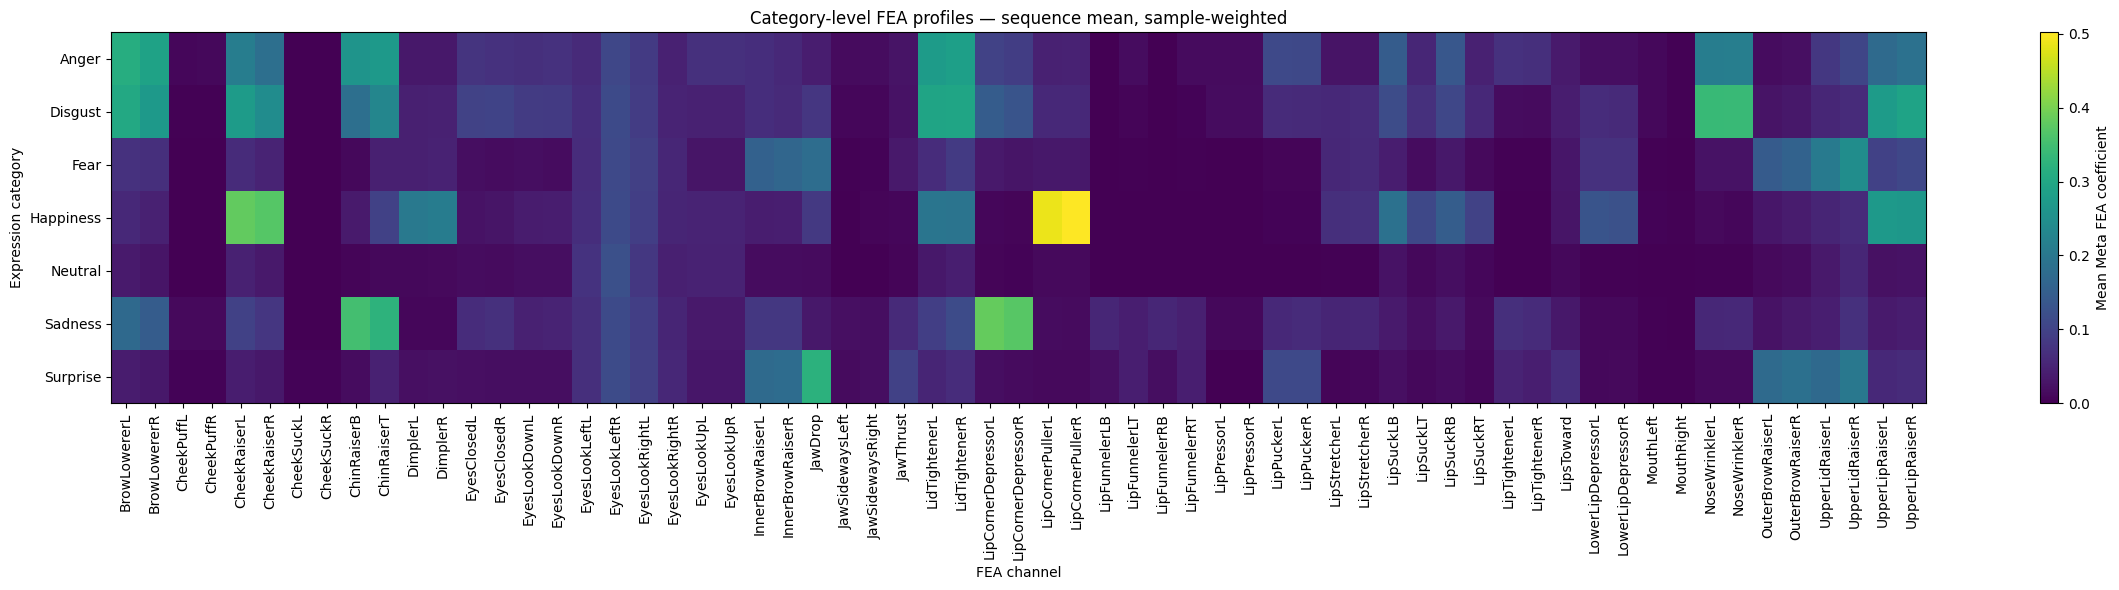

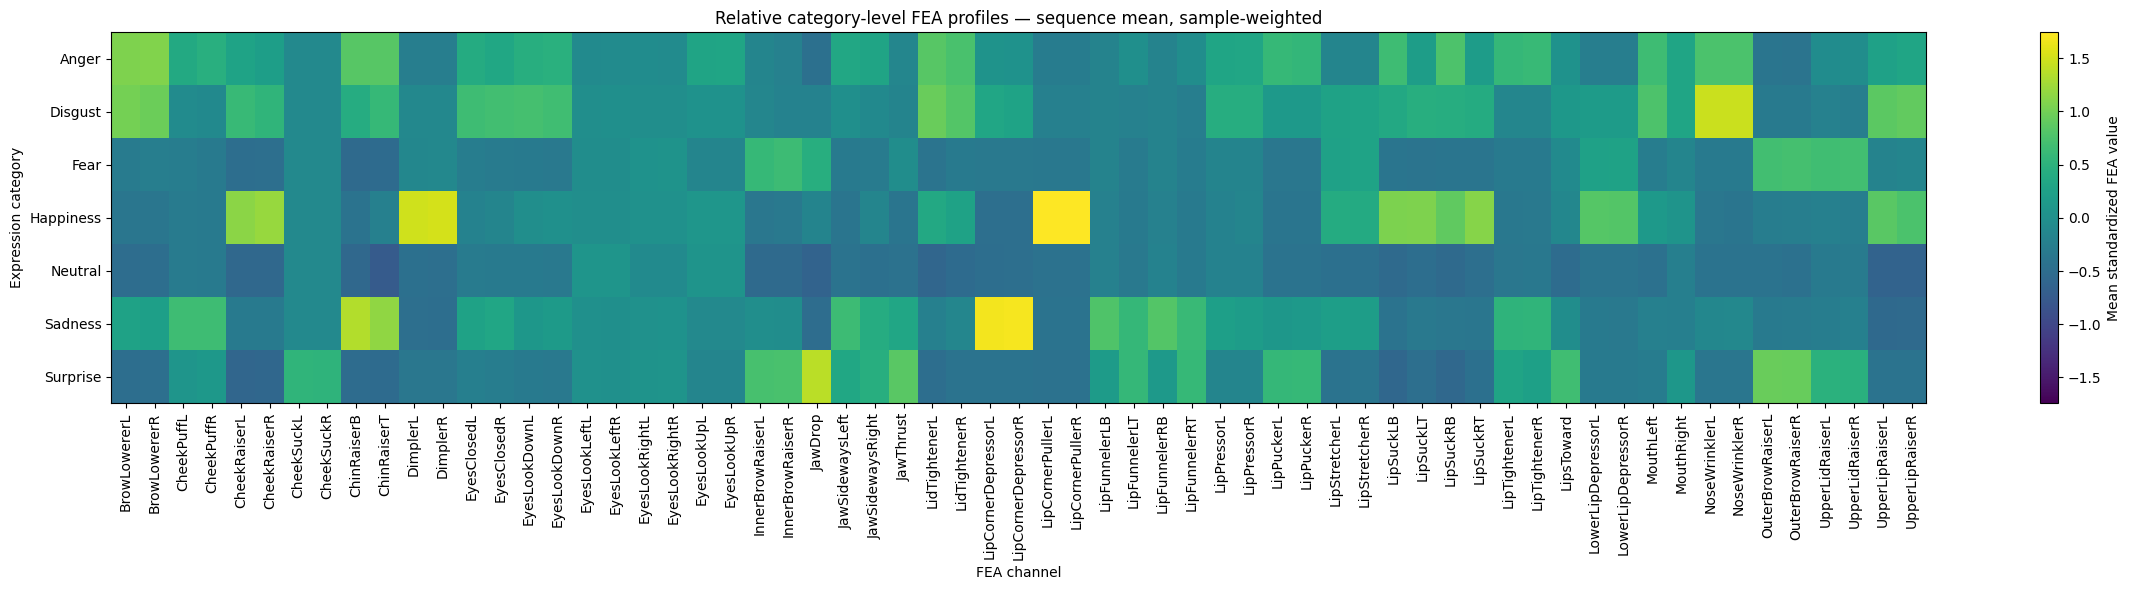

In [9]:
def save_heatmap(
    matrix,
    title,
    colorbar_label,
    filename_stem,
    figsize=(24, 6),
    vmin=None,
    vmax=None,
):
    plt.figure(figsize=figsize)
    image = plt.imshow(
        matrix.to_numpy(),
        aspect="auto",
        vmin=vmin,
        vmax=vmax,
    )
    plt.colorbar(image, label=colorbar_label)
    plt.xticks(
        np.arange(matrix.shape[1]),
        matrix.columns,
        rotation=90,
    )
    plt.yticks(
        np.arange(matrix.shape[0]),
        matrix.index,
    )
    plt.xlabel("FEA channel")
    plt.ylabel("Expression category")
    plt.title(title)
    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / f"{filename_stem}.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.savefig(
        OUTPUT_DIR / f"{filename_stem}.pdf",
        bbox_inches="tight",
    )
    plt.show()


primary_raw = fea_profiles[("mean", "raw", "sample_weighted")]
primary_standardized = fea_profiles[("mean", "standardized", "sample_weighted")]


save_heatmap(
    primary_raw,
    "Category-level FEA profiles — sequence mean, sample-weighted",
    "Mean Meta FEA coefficient",
    "fea_category_mean_sample_weighted_raw",
    vmin=0,
)

standardized_limit = float(
    np.nanmax(np.abs(primary_standardized.to_numpy()))
)
save_heatmap(
    primary_standardized,
    "Relative category-level FEA profiles — sequence mean, sample-weighted",
    "Mean standardized FEA value",
    "fea_category_mean_sample_weighted_standardized",
    vmin=-standardized_limit,
    vmax=standardized_limit,
)


## 10. Robustness views: participant balancing, P90, and neutral centering

These are not alternative definitions of the main result. They test whether the main category patterns persist under reasonable changes in aggregation.


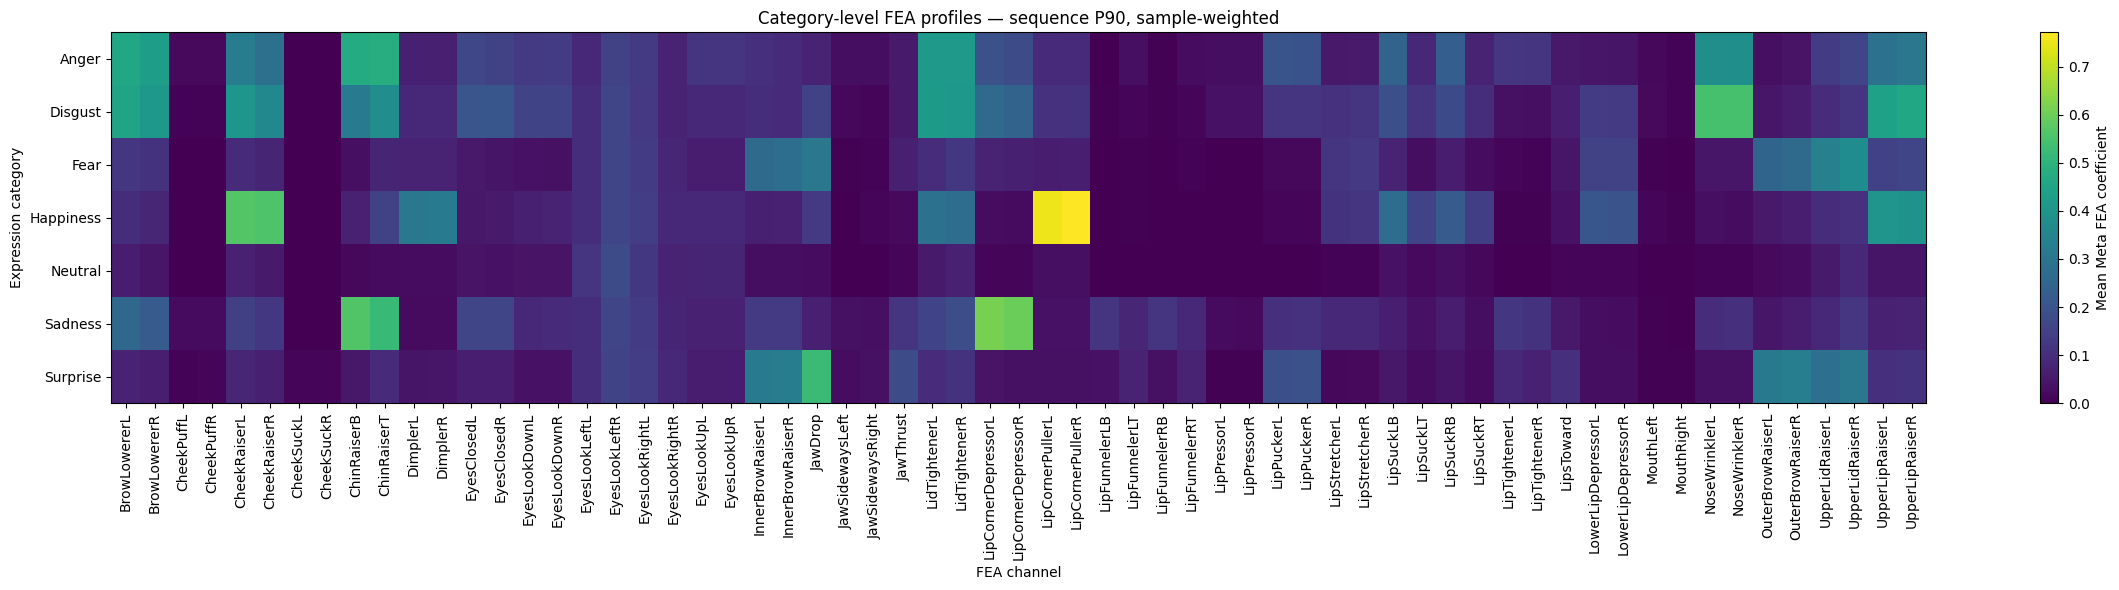

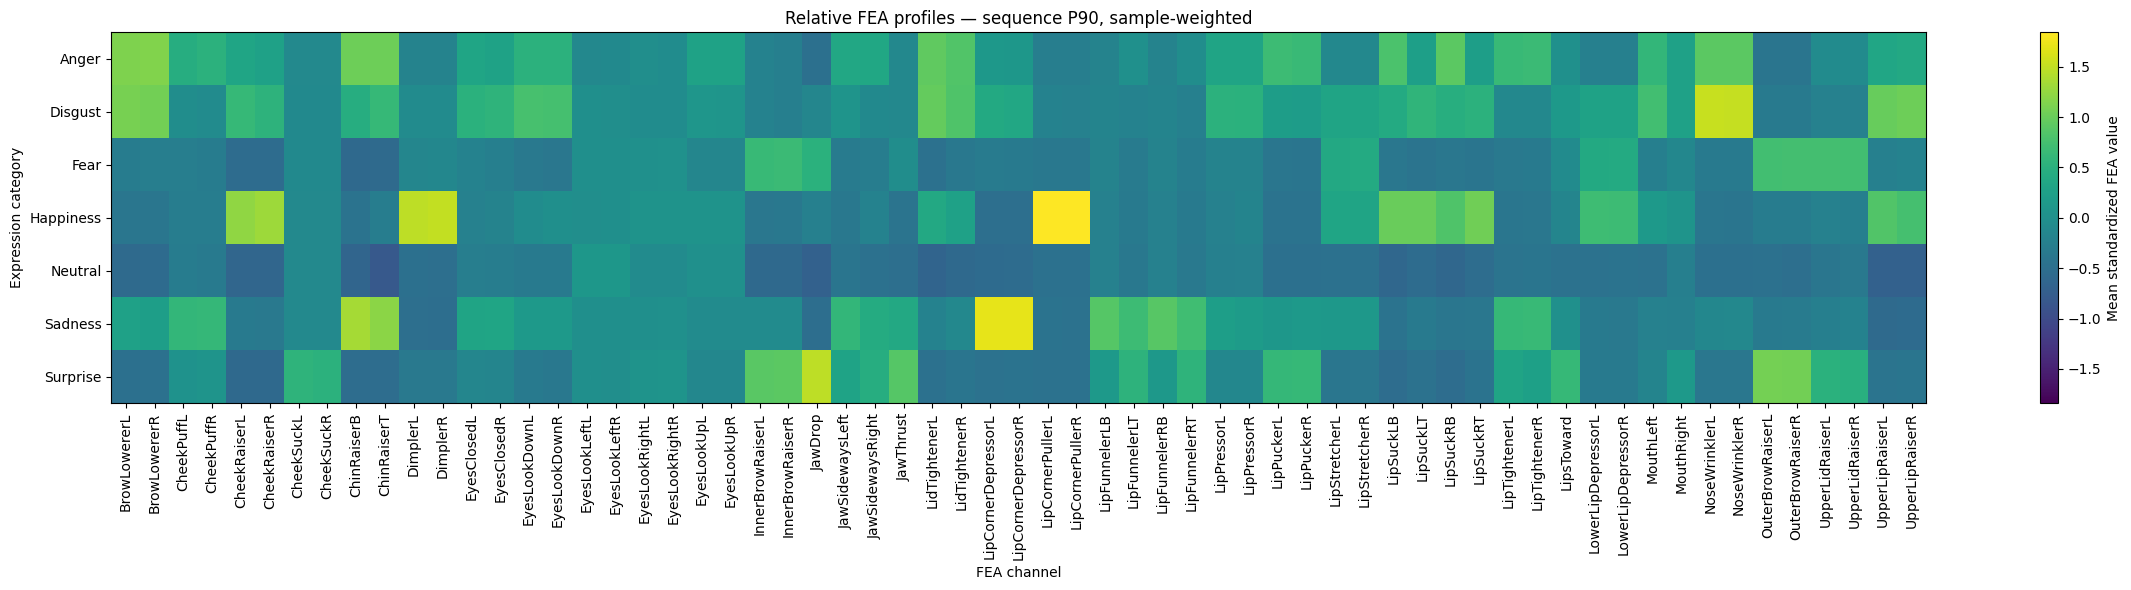

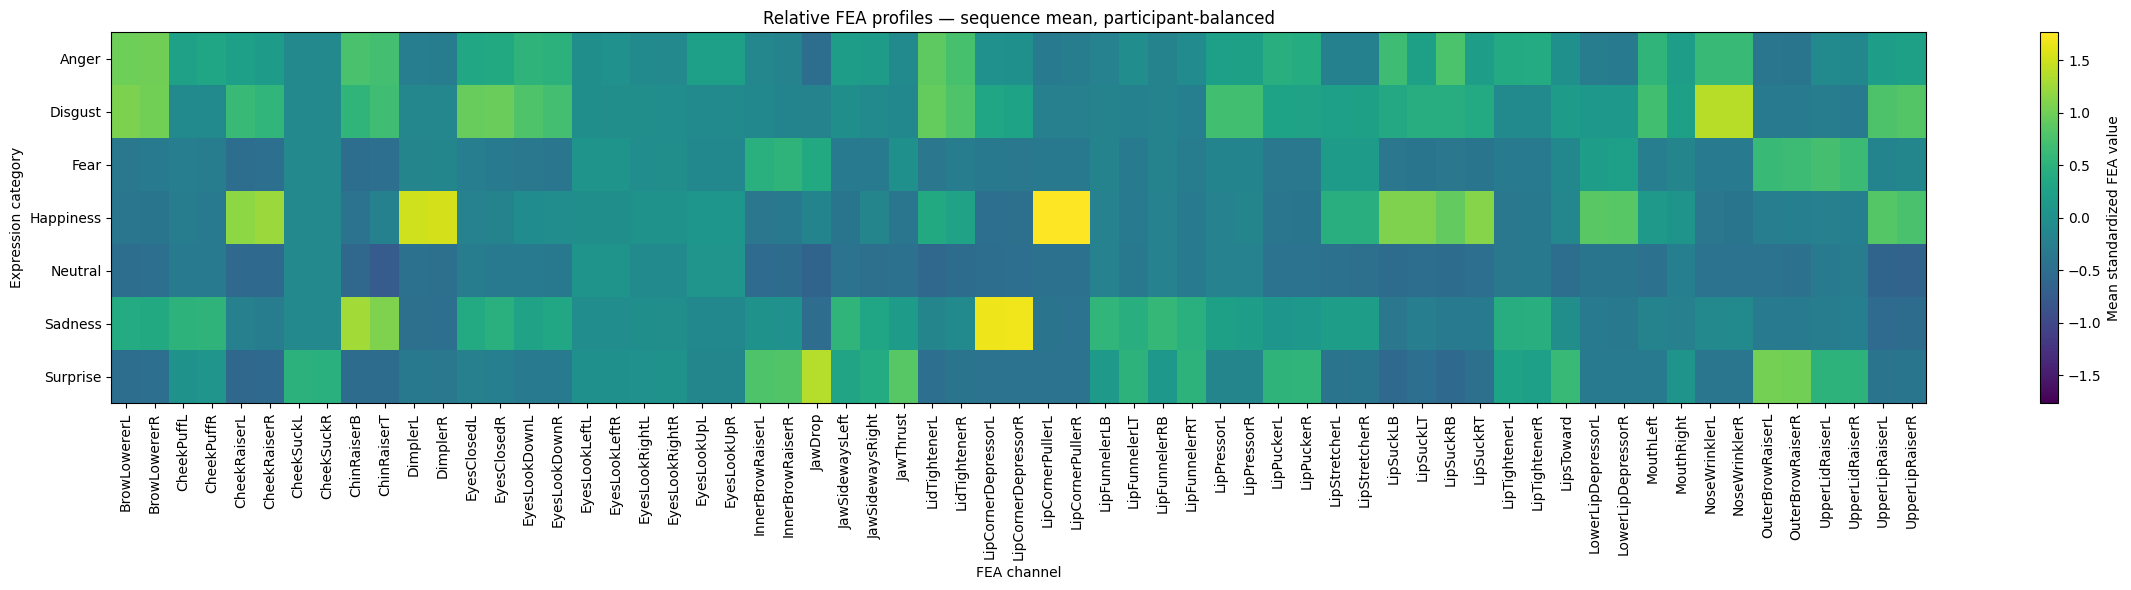

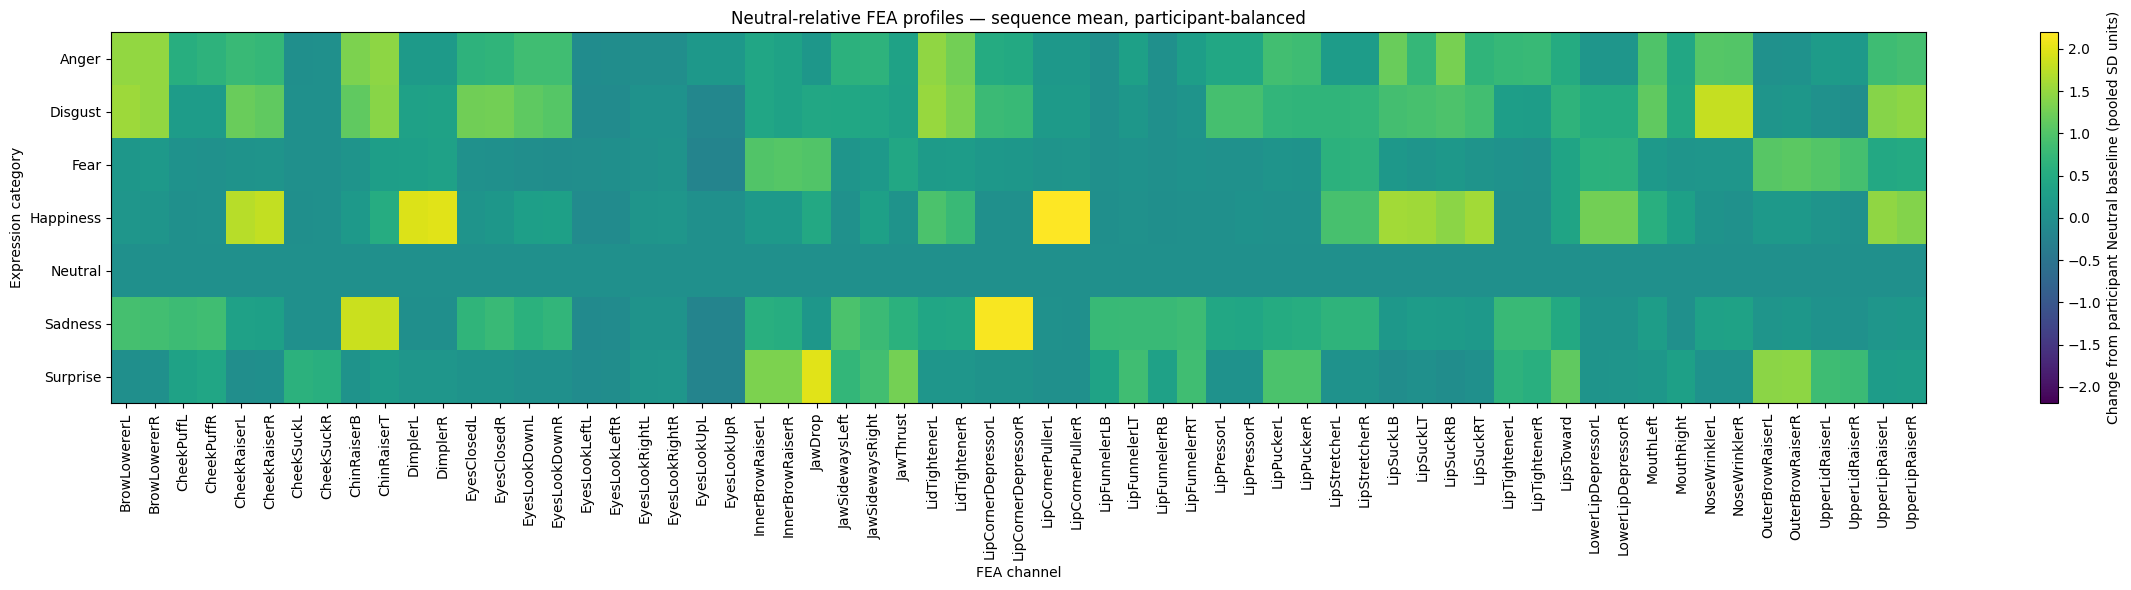

In [10]:
p90_raw = fea_profiles[
    ("p90", "raw", "sample_weighted")
]

p90_standardized = fea_profiles[
    ("p90", "standardized", "sample_weighted")
]

participant_balanced_standardized = fea_profiles[
    ("mean", "standardized", "participant_balanced")
]

neutral_standardized = fea_profiles[
    ("mean", "neutral_centered_standardized", "participant_balanced")
]


save_heatmap(
    p90_raw,
    "Category-level FEA profiles — sequence P90, sample-weighted",
    "Mean Meta FEA coefficient",
    "fea_category_p90_mean_sample_weighted_raw",
    vmin=0,
)

limit = float(np.nanmax(np.abs(p90_standardized.to_numpy())))
save_heatmap(
    p90_standardized,
    "Relative FEA profiles — sequence P90, sample-weighted",
    "Mean standardized FEA value",
    "fea_category_p90_sample_weighted_standardized",
    vmin=-limit,
    vmax=limit,
)

limit = float(np.nanmax(np.abs(participant_balanced_standardized.to_numpy())))
save_heatmap(
    participant_balanced_standardized,
    "Relative FEA profiles — sequence mean, participant-balanced",
    "Mean standardized FEA value",
    "fea_category_mean_participant_balanced_standardized",
    vmin=-limit,
    vmax=limit,
)

limit = float(np.nanmax(np.abs(neutral_standardized.to_numpy())))
save_heatmap(
    neutral_standardized,
    "Neutral-relative FEA profiles — sequence mean, participant-balanced",
    "Change from participant Neutral baseline (pooled SD units)",
    "fea_category_mean_participant_balanced_neutral_standardized",
    vmin=-limit,
    vmax=limit,
)


## 11. Quantify robustness across aggregation choices

Pearson correlations are computed across the flattened 7 × 63 category-profile matrices.

These are descriptive similarity measures, not inferential tests.


In [11]:
def matrix_correlation(a, b):
    x = a.to_numpy().ravel()
    y = b.to_numpy().ravel()
    return float(np.corrcoef(x, y)[0, 1])

robustness_rows = [
    {
        "comparison": "Mean: sample-weighted vs participant-balanced",
        "representation": "standardized",
        "correlation": matrix_correlation(
            fea_profiles[("mean", "standardized", "sample_weighted")],
            fea_profiles[("mean", "standardized", "participant_balanced")],
        ),
    },
    {
        "comparison": "P90: sample-weighted vs participant-balanced",
        "representation": "standardized",
        "correlation": matrix_correlation(
            fea_profiles[("p90", "standardized", "sample_weighted")],
            fea_profiles[("p90", "standardized", "participant_balanced")],
        ),
    },
    {
        "comparison": "Sample-weighted: Mean vs P90",
        "representation": "standardized",
        "correlation": matrix_correlation(
            fea_profiles[("mean", "standardized", "sample_weighted")],
            fea_profiles[("p90", "standardized", "sample_weighted")],
        ),
    },
    {
        "comparison": "Participant-balanced: Mean vs P90",
        "representation": "standardized",
        "correlation": matrix_correlation(
            fea_profiles[("mean", "standardized", "participant_balanced")],
            fea_profiles[("p90", "standardized", "participant_balanced")],
        ),
    },
]

robustness_summary = pd.DataFrame(robustness_rows)
robustness_summary.to_csv(
    OUTPUT_DIR / "fea_profile_aggregation_robustness.csv",
    index=False,
)
display(robustness_summary)


,comparison,representation,correlation
0,Mean: sample-weighted vs participant-balanced,standardized,0.992600
1,P90: sample-weighted vs participant-balanced,standardized,0.993921
2,Sample-weighted: Mean vs P90,standardized,0.995597
3,Participant-balanced: Mean vs P90,standardized,0.994540


## 12. Split-specific consistency of category profiles

The same pooled standardization parameters are used for every split so that train, validation, and test remain on a common scale.

The split comparisons are descriptive. Different participant composition can produce genuine marginal differences.


In [12]:
split_profiles = {}

mean_mu = standardization["mean"]["mean"]
mean_sigma = standardization["mean"]["std"]

for split in SPLITS:
    split_mean = sequence_summaries["mean"].loc[
        sequence_summaries["mean"]["split"] == split
    ].copy()

    split_standardized = split_mean.copy()
    split_standardized[FEA_COLUMNS] = (
        split_mean[FEA_COLUMNS] - mean_mu
    ) / mean_sigma

    split_profiles[split] = aggregate_category_profile(
        split_standardized,
        FEA_COLUMNS,
        "sample_weighted",
    )

split_similarity_rows = []
for i, split_a in enumerate(SPLITS):
    for split_b in SPLITS[i + 1:]:
        split_similarity_rows.append({
            "split_a": split_a,
            "split_b": split_b,
            "profile_correlation": matrix_correlation(
                split_profiles[split_a],
                split_profiles[split_b],
            ),
        })

split_similarity = pd.DataFrame(split_similarity_rows)
split_similarity.to_csv(
    OUTPUT_DIR / "fea_category_profile_split_similarity.csv",
    index=False,
)
display(split_similarity)


,split_a,split_b,profile_correlation
0,train,validation,0.866809
1,train,test,0.825934
2,validation,test,0.804080


# FACS-related semantic group summaries

The remaining sections reduce the 63 FEA channels into interpretable semantic groups.

The grouping follows `facs_fea_mapping.json`:

- direct/component AU correspondences;
- Action Descriptors (ADs);
- approximate eye-position correspondences;
- the two channels without a unique single FACS correspondence remain separate unmapped groups.

The value of a semantic group is the **mean of its member FEA sequence summaries**. For example, the AU12-related group averages `LipCornerPullerL` and `LipCornerPullerR`.

For P90, P90 is first computed independently for each FEA channel within a reenactment and the resulting channel summaries are then averaged within the semantic group. This avoids defining a new synthetic time series before computing the quantile.


## 13. Build semantic group definitions


In [13]:
def semantic_group_id(row):
    if row["facs_kind"] == "unmapped":
        return f"UNMAPPED_{row['fea_name']}"
    return row["facs_code"]


def semantic_group_label(row):
    if row["facs_kind"] == "unmapped":
        return f"{row['fea_name']} (unmapped)"
    return f"{row['facs_code']} {row['facs_name']}"


mapping_work = mapping_df.copy()
mapping_work["group_id"] = mapping_work.apply(semantic_group_id, axis=1)
mapping_work["group_label"] = mapping_work.apply(semantic_group_label, axis=1)


def numeric_suffix(text):
    match = re.search(r"(\d+)", str(text))
    return int(match.group(1)) if match else 9999


kind_order = {
    "AU": 0,
    "AD": 1,
    "eye_position": 2,
    "unmapped": 3,
}

group_definitions = (
    mapping_work
    .groupby(["group_id", "group_label", "facs_kind"], dropna=False, observed=True)
    .agg(
        fea_count=("fea_name", "size"),
        fea_names=("fea_name", lambda s: " | ".join(s)),
        mapping_statuses=("mapping_status", lambda s: " | ".join(sorted(set(s)))),
    )
    .reset_index()
)

group_definitions["_kind_order"] = group_definitions["facs_kind"].map(kind_order)
group_definitions["_number"] = group_definitions["group_id"].map(numeric_suffix)

group_definitions = (
    group_definitions
    .sort_values(["_kind_order", "_number", "group_label"])
    .drop(columns=["_kind_order", "_number"])
    .reset_index(drop=True)
)

GROUP_IDS = group_definitions["group_id"].tolist()
GROUP_LABEL_BY_ID = dict(
    zip(group_definitions["group_id"], group_definitions["group_label"])
)

group_members = {
    group_id: (
        mapping_work.loc[mapping_work["group_id"] == group_id, "fea_name"]
        .tolist()
    )
    for group_id in GROUP_IDS
}

assert len(GROUP_IDS) == 32
assert sorted(
    fea
    for members in group_members.values()
    for fea in members
) == sorted(FEA_COLUMNS)

group_definitions.to_csv(
    OUTPUT_DIR / "semantic_fea_group_definitions.csv",
    index=False,
)

display(group_definitions)


,group_id,group_label,facs_kind,fea_count,fea_names,mapping_statuses
0,AU1,AU1 Inner Brow Raiser,AU,2,InnerBrowRaiserL | InnerBrowRaiserR,direct_semantic_correspondence
1,AU2,AU2 Outer Brow Raiser,AU,2,OuterBrowRaiserL | OuterBrowRaiserR,direct_semantic_correspondence
2,AU4,AU4 Brow Lowerer,AU,2,BrowLowererL | BrowLowererR,direct_semantic_correspondence
3,AU5,AU5 Upper Lid Raiser,AU,2,UpperLidRaiserL | UpperLidRaiserR,direct_semantic_correspondence
4,AU6,AU6 Cheek Raiser,AU,2,CheekRaiserL | CheekRaiserR,direct_semantic_correspondence
5,AU7,AU7 Lid Tightener,AU,2,LidTightenerL | LidTightenerR,direct_semantic_correspondence
6,AU8,AU8 Lips Toward Each Other,AU,1,LipsToward,direct_semantic_correspondence
7,AU9,AU9 Nose Wrinkler,AU,2,NoseWrinklerL | NoseWrinklerR,direct_semantic_correspondence
8,AU10,AU10 Upper Lip Raiser,AU,2,UpperLipRaiserL | UpperLipRaiserR,direct_semantic_correspondence
9,AU12,AU12 Lip Corner Puller,AU,2,LipCornerPullerL | LipCornerPullerR,direct_semantic_correspondence


## 14. Compute reenactment-level semantic group summaries

Grouping is applied separately to the sequence Mean and P90 tables.


In [14]:
def build_group_summary(sequence_df):
    result = sequence_df[REENACTMENT_META].copy()

    for group_id in GROUP_IDS:
        members = group_members[group_id]
        result[group_id] = sequence_df[members].mean(axis=1)

    return result


group_sequence_summaries = {
    metric: build_group_summary(sequence_summaries[metric])
    for metric in ["mean", "p90"]
}

for metric, df in group_sequence_summaries.items():
    df.to_csv(
        OUTPUT_DIR / f"reenactment_semantic_group_{metric}.csv",
        index=False,
    )

display(group_sequence_summaries["mean"].head())


,reenactment_id,split,sequence_timestamp,set_id,participant_id,level_id,emoji_id,true_label_id,true_label,AU1,AU2,AU4,AU5,AU6,AU7,AU8,AU9,AU10,AU12,AU14,AU15,AU16,AU17,AU18,AU20,AU22,AU23,AU24,AU26,AU28,AU43,AD29,AD30,AD34,AD35,EYE61,EYE62,EYE63,EYE64,UNMAPPED_MouthLeft,UNMAPPED_MouthRight
0,1700478995850-2-1-1-0-0,test,1700478995850,2,1,1,0,0,Anger,0.063022,0.000053,0.235825,1.401298e-45,0.069559,0.092547,0.034223,2.997242e-03,0.013501,1.384770e-15,3.730760e-17,0.021763,9.910236e-03,0.189695,0.252695,0.004712,2.425011e-02,1.243170e-01,1.401298e-45,0.027385,0.008635,0.018857,0.016728,0.051800,4.649676e-02,1.401298e-45,0.029825,0.020490,0.068004,0.005798,1.005199e-08,6.979022e-09
1,1700478998549-2-1-1-1-5,test,1700478998549,2,1,1,1,5,Sadness,0.063144,0.005706,0.069745,1.401298e-45,0.028389,0.009440,0.021351,2.077896e-03,0.000003,1.791377e-05,1.268053e-05,0.805699,8.821490e-04,0.363436,0.030496,0.136492,5.131678e-02,5.605063e-02,1.401298e-45,0.019430,0.006964,0.015905,0.048600,0.020726,6.875202e-03,1.401298e-45,0.022265,0.021030,0.000000,0.048964,9.391553e-11,7.925856e-21
2,1700479001137-2-1-1-2-3,test,1700479001137,2,1,1,2,3,Happiness,0.030857,0.036831,0.000002,1.401298e-45,0.162243,0.055305,0.028743,8.124459e-15,0.626706,3.554379e-01,4.777791e-01,0.013234,1.983385e-01,0.082868,0.000536,0.248125,2.677908e-16,4.691582e-17,6.774103e-10,0.560646,0.117963,0.004879,0.299710,0.004779,2.431802e-11,1.401298e-45,0.096852,0.000000,0.044625,0.004772,6.905036e-23,6.572523e-04
3,1700479004312-2-1-1-3-0,test,1700479004312,2,1,1,3,0,Anger,0.006198,0.000536,0.029568,1.401298e-45,0.030088,0.042171,0.022622,9.686588e-11,0.013681,5.314752e-04,5.515129e-23,0.008154,3.222509e-20,0.033755,0.054775,0.001266,1.962072e-03,3.271961e-02,1.115704e-04,0.014463,0.036302,0.001567,0.003463,0.007325,2.499230e-03,1.401298e-45,0.000000,0.091013,0.196183,0.000000,1.966048e-04,7.260990e-04
4,1700479005401-2-1-1-4-0,test,1700479005401,2,1,1,4,0,Anger,0.084329,0.000104,0.267518,1.401298e-45,0.051843,0.076025,0.028063,6.253740e-17,0.013358,4.075645e-08,3.557301e-29,0.024229,2.079471e-26,0.177082,0.199398,0.006781,1.059540e-02,1.243949e-01,2.546441e-04,0.016553,0.031395,0.015486,0.017693,0.027393,1.184527e-02,1.401298e-45,0.008377,0.034869,0.171506,0.000000,1.249324e-04,1.693865e-03


## 15. Standardized and neutral-centered semantic group profiles

Semantic-group standardization is performed **after grouping** at the reenactment level. This makes every semantic group a single analysis variable before cross-group comparison.


In [15]:
derived_group_summaries = {}
group_standardization = {}

for metric, df in group_sequence_summaries.items():
    standardized, mu, sigma = add_standardized_values(df, GROUP_IDS)
    neutral_centered, _ = add_neutral_centered_values(df, GROUP_IDS)

    neutral_standardized = neutral_centered.copy()
    neutral_standardized[GROUP_IDS] = (
        neutral_centered[GROUP_IDS] / sigma
    )

    derived_group_summaries[(metric, "raw")] = df
    derived_group_summaries[(metric, "standardized")] = standardized
    derived_group_summaries[(metric, "neutral_centered")] = neutral_centered
    derived_group_summaries[(metric, "neutral_centered_standardized")] = neutral_standardized

    group_standardization[metric] = {"mean": mu, "std": sigma}


group_profiles = {}

for metric in ["mean", "p90"]:
    for representation in REPRESENTATIONS:
        source = derived_group_summaries[(metric, representation)]
        for weighting in WEIGHTINGS:
            group_profiles[(metric, representation, weighting)] = (
                aggregate_category_profile(
                    source,
                    GROUP_IDS,
                    weighting,
                )
            )

group_profile_rows = []

for (metric, representation, weighting), profile in group_profiles.items():
    long = (
        profile
        .reset_index()
        .melt(
            id_vars="true_label",
            var_name="group_id",
            value_name="value",
        )
    )
    long["group_label"] = long["group_id"].map(GROUP_LABEL_BY_ID)
    long.insert(0, "weighting", weighting)
    long.insert(0, "representation", representation)
    long.insert(0, "sequence_summary", metric)
    group_profile_rows.append(long)

group_profiles_long = pd.concat(group_profile_rows, ignore_index=True)

group_profiles_long.to_csv(
    OUTPUT_DIR / "category_semantic_group_profiles_long.csv",
    index=False,
)

display(group_profiles_long.head())


,sequence_summary,representation,weighting,true_label,group_id,value,group_label
0,mean,raw,sample_weighted,Anger,AU1,0.061534,AU1 Inner Brow Raiser
1,mean,raw,sample_weighted,Disgust,AU1,0.063001,AU1 Inner Brow Raiser
2,mean,raw,sample_weighted,Fear,AU1,0.161040,AU1 Inner Brow Raiser
3,mean,raw,sample_weighted,Happiness,AU1,0.040725,AU1 Inner Brow Raiser
4,mean,raw,sample_weighted,Neutral,AU1,0.017333,AU1 Inner Brow Raiser


## 16. Heatmaps of all semantic FEA groups

These plots retain AU-related groups, Action Descriptors, approximate eye-position groups, and the two unmapped channels.


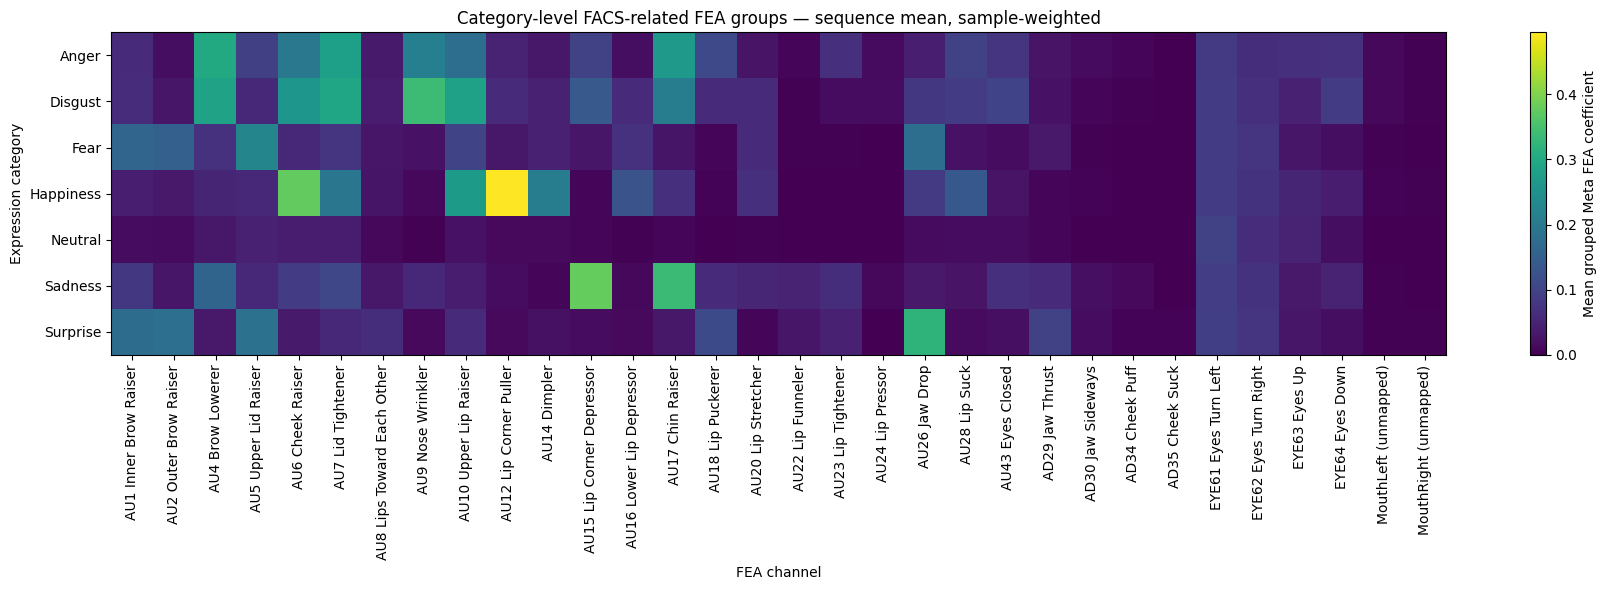

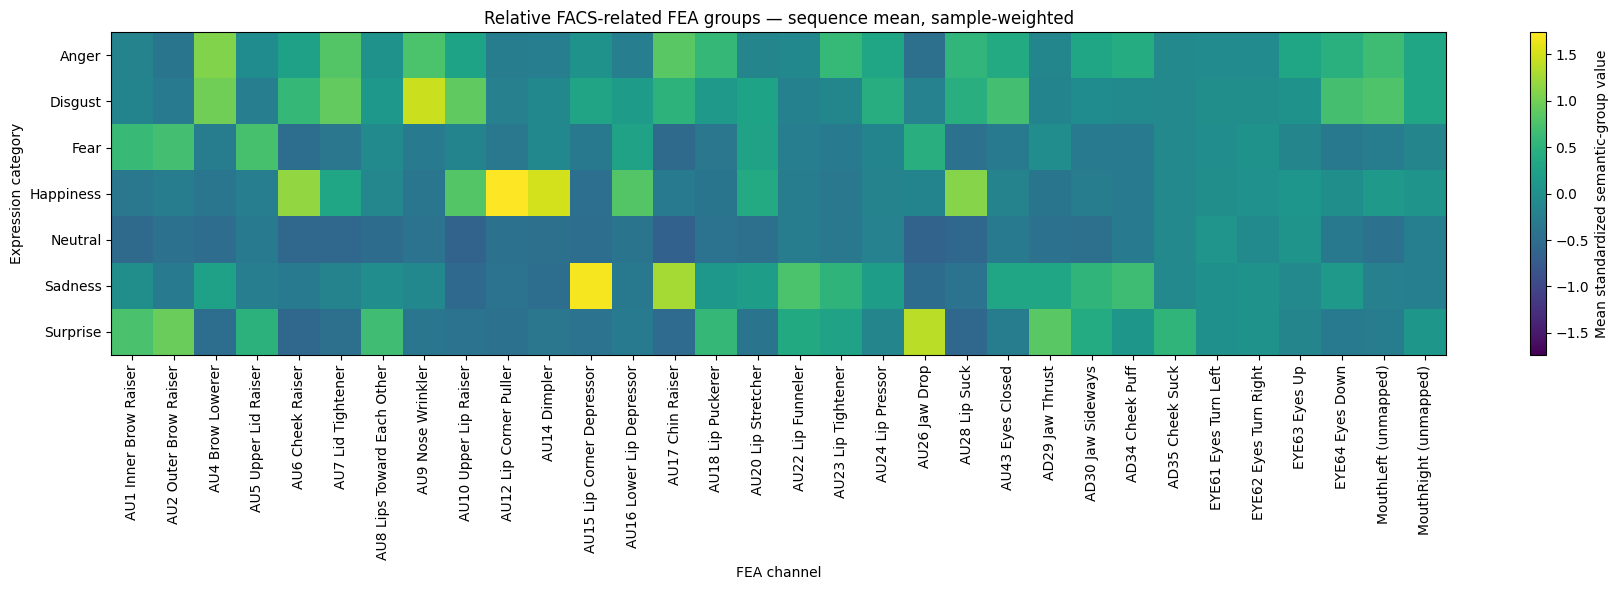

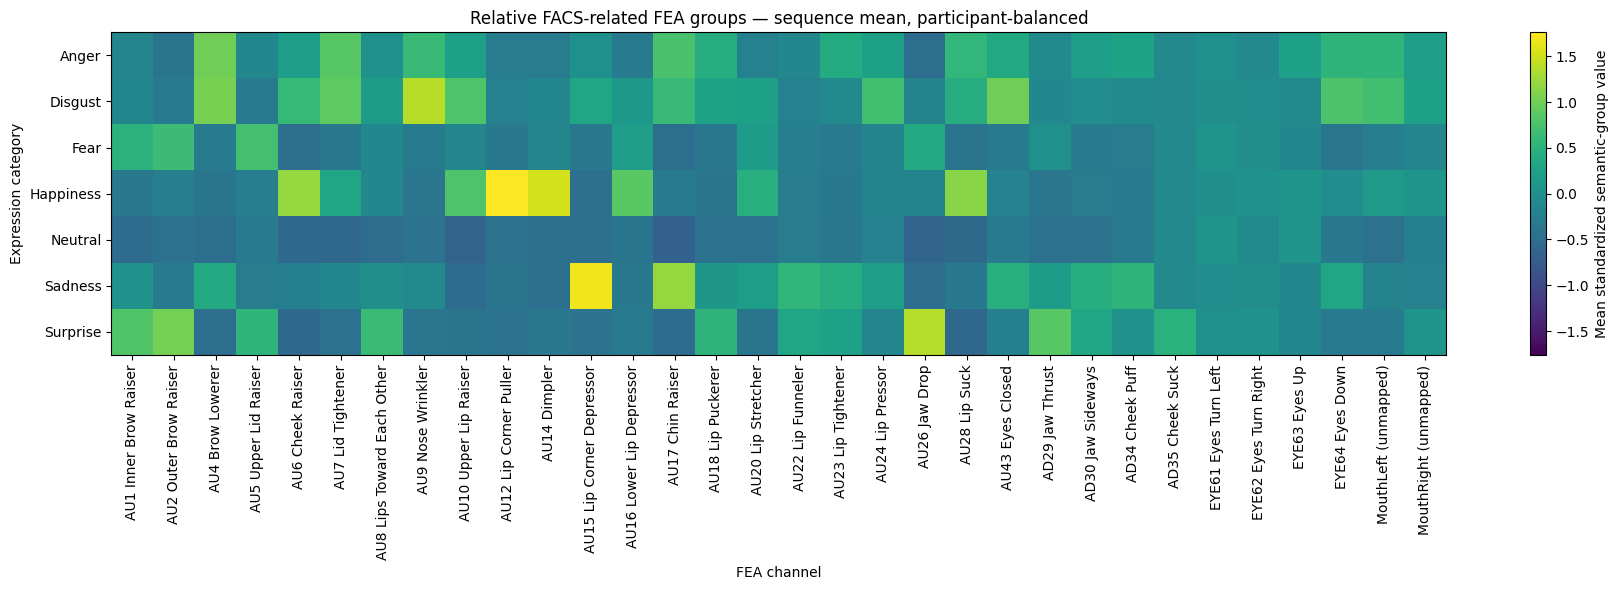

In [16]:
def relabel_group_columns(profile):
    result = profile.copy()
    result.columns = [GROUP_LABEL_BY_ID[c] for c in result.columns]
    return result


all_group_raw = relabel_group_columns(
    group_profiles[("mean", "raw", "sample_weighted")]
)
all_group_standardized = relabel_group_columns(
    group_profiles[("mean", "standardized", "sample_weighted")]
)
all_group_participant = relabel_group_columns(
    group_profiles[("mean", "standardized", "participant_balanced")]
)

save_heatmap(
    all_group_raw,
    "Category-level FACS-related FEA groups — sequence mean, sample-weighted",
    "Mean grouped Meta FEA coefficient",
    "semantic_groups_mean_sample_weighted_raw",
    figsize=(18, 6),
    vmin=0,
)

limit = float(np.nanmax(np.abs(all_group_standardized.to_numpy())))
save_heatmap(
    all_group_standardized,
    "Relative FACS-related FEA groups — sequence mean, sample-weighted",
    "Mean standardized semantic-group value",
    "semantic_groups_mean_sample_weighted_standardized",
    figsize=(18, 6),
    vmin=-limit,
    vmax=limit,
)

limit = float(np.nanmax(np.abs(all_group_participant.to_numpy())))
save_heatmap(
    all_group_participant,
    "Relative FACS-related FEA groups — sequence mean, participant-balanced",
    "Mean standardized semantic-group value",
    "semantic_groups_mean_participant_balanced_standardized",
    figsize=(18, 6),
    vmin=-limit,
    vmax=limit,
)


## 17. Paper-relevant AU-related groups

The current manuscript's FACS table contains 20 unique AUs. Seventeen have at least one dedicated semantic FEA correspondence in the 63-channel schema; AU11, AU25, and AU27 do not.

This section creates a compact profile containing only the 17 mapped manuscript AUs. Together with the individual-FEA view in Section 18 and the category-level interpretation below, these analyses provide the **descriptive non-temporal comparison** between the observed FEA patterns and the manuscript's theoretical FACS configurations.

This comparison should not be interpreted as validation of the Meta coefficients as FACS AU measurements or as a binary AU match/no-match test. Temporal correspondence between FEA activations and model predictions remains to be examined separately in the trajectory analyses.


In [17]:
paper_au_rows = pd.DataFrame(mapping["paper_table"]["au_to_fea"])

mapped_paper_aus = (
    paper_au_rows.loc[paper_au_rows["fea_count"] > 0]
    .sort_values("au_number")
    .reset_index(drop=True)
)

missing_paper_aus = (
    paper_au_rows.loc[paper_au_rows["fea_count"] == 0]
    .sort_values("au_number")
    .reset_index(drop=True)
)

PAPER_AU_IDS = mapped_paper_aus["au_code"].tolist()

assert len(PAPER_AU_IDS) == 17
assert set(PAPER_AU_IDS).issubset(set(GROUP_IDS))

mapped_paper_aus.to_csv(
    OUTPUT_DIR / "paper_mapped_au_groups.csv",
    index=False,
)
missing_paper_aus.to_csv(
    OUTPUT_DIR / "paper_aus_without_dedicated_fea.csv",
    index=False,
)

display(mapped_paper_aus[
    [
        "au_code",
        "au_name",
        "paper_face_region",
        "paper_expression_categories",
        "fea_names",
    ]
])

print("Paper AUs without a dedicated FEA:")
display(missing_paper_aus[
    ["au_code", "au_name", "paper_expression_categories", "notes"]
])


,au_code,au_name,paper_face_region,paper_expression_categories,fea_names
0,AU1,Inner Brow Raiser,upper,Fear | Sadness | Surprise,InnerBrowRaiserL | InnerBrowRaiserR
1,AU2,Outer Brow Raiser,upper,Fear | Surprise,OuterBrowRaiserL | OuterBrowRaiserR
2,AU4,Brow Lowerer,upper,Anger | Fear | Sadness,BrowLowererL | BrowLowererR
3,AU5,Upper Lid Raiser,upper,Anger | Fear | Surprise,UpperLidRaiserL | UpperLidRaiserR
4,AU6,Cheek Raiser,upper,Happiness | Sadness,CheekRaiserL | CheekRaiserR
5,AU7,Lid Tightener,upper,Anger,LidTightenerL | LidTightenerR
6,AU9,Nose Wrinkler,lower,Disgust,NoseWrinklerL | NoseWrinklerR
7,AU10,Upper Lip Raiser,lower,Anger | Disgust,UpperLipRaiserL | UpperLipRaiserR
8,AU12,Lip Corner Puller,lower,Happiness,LipCornerPullerL | LipCornerPullerR
9,AU15,Lip Corner Depressor,lower,Disgust | Sadness,LipCornerDepressorL | LipCornerDepressorR


Paper AUs without a dedicated FEA:


,au_code,au_name,paper_expression_categories,notes
0,AU11,Nasolabial Deepener,Sadness,No dedicated FEA channel in the 63-channel Emo...
1,AU25,Lips Part,Anger | Disgust | Fear | Sadness,No dedicated FEA channel. Neither JawDrop nor ...
2,AU27,Mouth Stretch,Fear | Surprise,No dedicated FEA channel. A high JawDrop value...


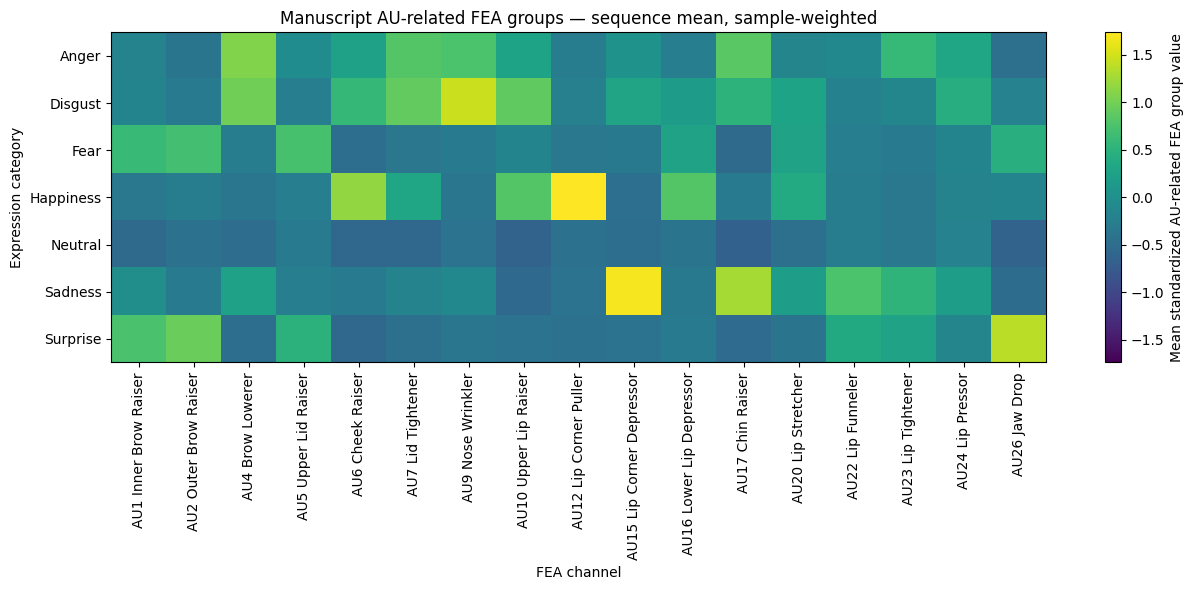

In [18]:
paper_group_profile = group_profiles[
    ("mean", "standardized", "sample_weighted")
][PAPER_AU_IDS].copy()

paper_group_profile.columns = [
    GROUP_LABEL_BY_ID[c]
    for c in paper_group_profile.columns
]

limit = float(np.nanmax(np.abs(paper_group_profile.to_numpy())))

save_heatmap(
    paper_group_profile,
    "Manuscript AU-related FEA groups — sequence mean, sample-weighted",
    "Mean standardized AU-related FEA group value",
    "paper_au_groups_mean_sample_weighted_standardized",
    figsize=(13, 6),
    vmin=-limit,
    vmax=limit,
)


## 18. Individual FEAs corresponding to manuscript-relevant AUs

The AU-group heatmap above is compact, but averaging multiple FEAs into one AU-related group can hide useful structure, such as left/right differences or differences between multiple Meta coefficients associated with the same AU-related movement.

This section therefore keeps the **individual FEA channels separate** while restricting the visualization to FEAs that correspond to the 17 manuscript AUs with a dedicated semantic FEA mapping.

The aggregation settings are kept identical to the AU-group heatmap for direct comparison:

- sequence summary: **Mean**;
- category aggregation: **sample-weighted**;
- representation: **standardized**.

The AU code is included in each x-axis label only to show the semantic correspondence. The plotted values remain the individual FEA-channel values; they are **not averaged by AU**.


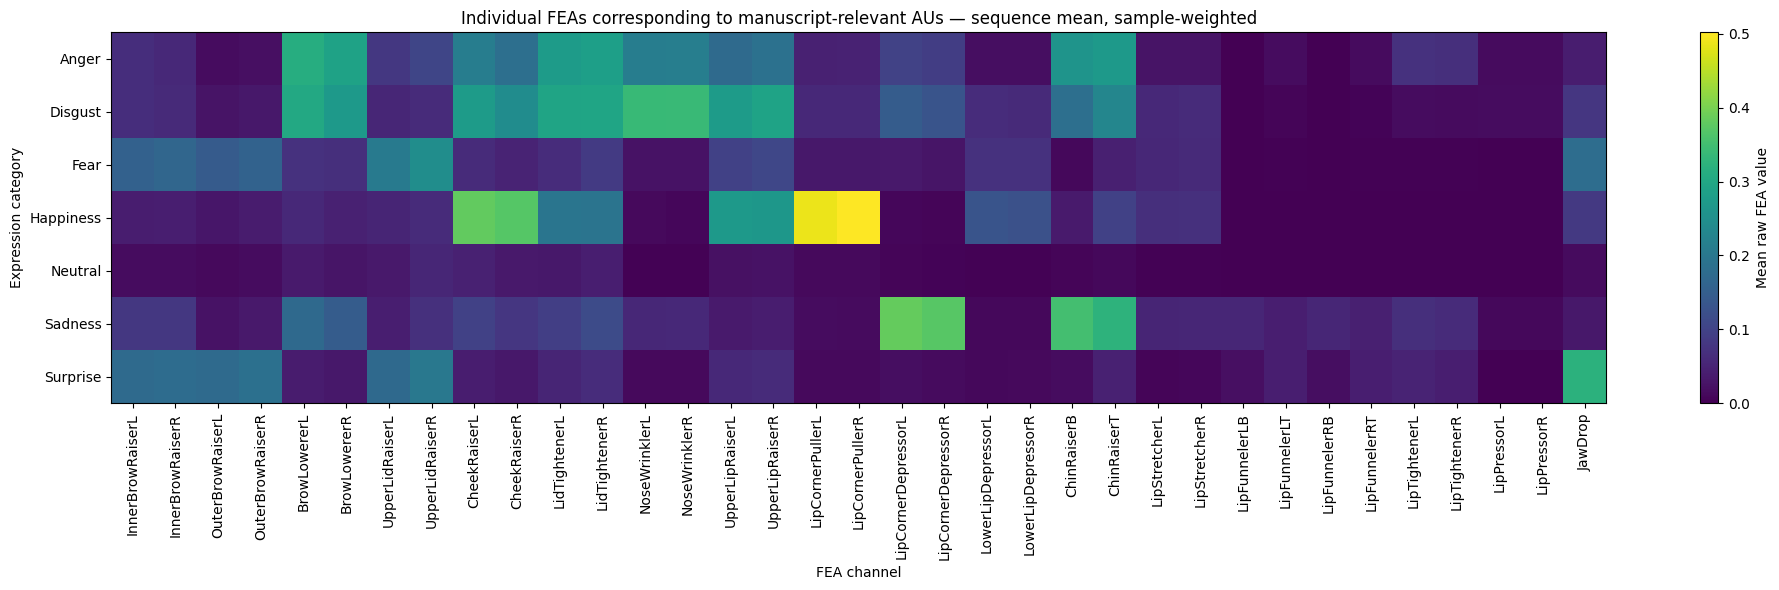

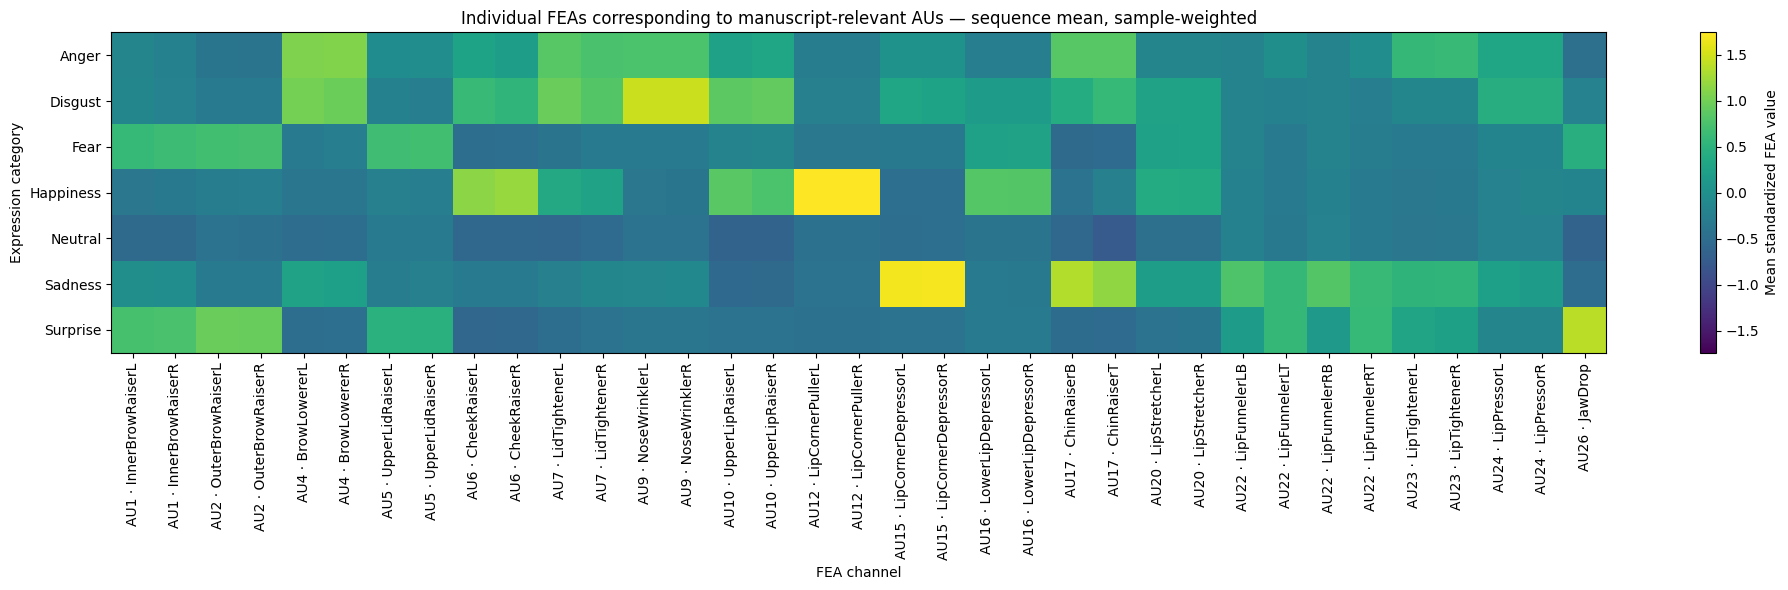

,au_code,au_name,fea_name,heatmap_label
0,AU1,Inner Brow Raiser,InnerBrowRaiserL,AU1 · InnerBrowRaiserL
1,AU1,Inner Brow Raiser,InnerBrowRaiserR,AU1 · InnerBrowRaiserR
2,AU2,Outer Brow Raiser,OuterBrowRaiserL,AU2 · OuterBrowRaiserL
3,AU2,Outer Brow Raiser,OuterBrowRaiserR,AU2 · OuterBrowRaiserR
4,AU4,Brow Lowerer,BrowLowererL,AU4 · BrowLowererL
5,AU4,Brow Lowerer,BrowLowererR,AU4 · BrowLowererR
6,AU5,Upper Lid Raiser,UpperLidRaiserL,AU5 · UpperLidRaiserL
7,AU5,Upper Lid Raiser,UpperLidRaiserR,AU5 · UpperLidRaiserR
8,AU6,Cheek Raiser,CheekRaiserL,AU6 · CheekRaiserL
9,AU6,Cheek Raiser,CheekRaiserR,AU6 · CheekRaiserR


In [19]:
paper_au_fea_pairs = []

for _, row in mapped_paper_aus.iterrows():
    fea_names = [
        name.strip()
        for name in row["fea_names"].split("|")
        if name.strip()
    ]

    for fea_name in fea_names:
        paper_au_fea_pairs.append({
            "au_code": row["au_code"],
            "au_name": row["au_name"],
            "fea_name": fea_name,
        })

paper_au_fea_pairs = pd.DataFrame(paper_au_fea_pairs)

PAPER_AU_FEA_COLUMNS = paper_au_fea_pairs["fea_name"].tolist()

assert len(PAPER_AU_FEA_COLUMNS) == len(set(PAPER_AU_FEA_COLUMNS))
assert set(PAPER_AU_FEA_COLUMNS).issubset(set(FEA_COLUMNS))

paper_au_fea_pairs["heatmap_label"] = (
    paper_au_fea_pairs["au_code"]
    + " · "
    + paper_au_fea_pairs["fea_name"]
)

paper_au_fea_pairs.to_csv(
    OUTPUT_DIR / "paper_relevant_au_fea_channels.csv",
    index=False,
)

paper_individual_raw_fea_profile = fea_profiles[
    ("mean", "raw", "sample_weighted")
][PAPER_AU_FEA_COLUMNS].copy()

paper_individual_fea_profile = fea_profiles[
    ("mean", "standardized", "sample_weighted")
][PAPER_AU_FEA_COLUMNS].copy()

paper_individual_fea_profile.columns = (
    paper_au_fea_pairs
    .set_index("fea_name")
    .loc[PAPER_AU_FEA_COLUMNS, "heatmap_label"]
    .tolist()
)

save_heatmap(
    paper_individual_raw_fea_profile,
    "Individual FEAs corresponding to manuscript-relevant AUs — sequence mean, sample-weighted",
    "Mean raw FEA value",
    "paper_au_individual_feas_mean_sample_weighted_raw",
    figsize=(20, 6),
    vmin=0
)


limit = float(
    np.nanmax(np.abs(paper_individual_fea_profile.to_numpy()))
)

save_heatmap(
    paper_individual_fea_profile,
    "Individual FEAs corresponding to manuscript-relevant AUs — sequence mean, sample-weighted",
    "Mean standardized FEA value",
    "paper_au_individual_feas_mean_sample_weighted_standardized",
    figsize=(20, 6),
    vmin=-limit,
    vmax=limit,
)

display(paper_au_fea_pairs)


## 19. Identify the strongest category-associated patterns

The rankings below use standardized sequence-mean profiles. They describe **category association**, not classifier importance.

For each category, the notebook exports the FEAs and semantic groups with the largest positive standardized deviations from the pooled reenactment distribution.


In [20]:
def top_patterns(profile, n=10, item_name="feature"):
    rows = []
    for category in CATEGORY_ORDER:
        ranked = profile.loc[category].sort_values(ascending=False).head(n)
        for rank, (item, value) in enumerate(ranked.items(), start=1):
            rows.append({
                "true_label": category,
                "rank": rank,
                item_name: item,
                "standardized_value": float(value),
            })
    return pd.DataFrame(rows)


top_fea_patterns = top_patterns(
    fea_profiles[("mean", "standardized", "sample_weighted")],
    n=10,
    item_name="fea_name",
)

top_group_patterns = top_patterns(
    group_profiles[("mean", "standardized", "sample_weighted")],
    n=10,
    item_name="group_id",
)
top_group_patterns["group_label"] = top_group_patterns["group_id"].map(
    GROUP_LABEL_BY_ID
)

top_fea_patterns.to_csv(
    OUTPUT_DIR / "top_category_associated_feas.csv",
    index=False,
)
top_group_patterns.to_csv(
    OUTPUT_DIR / "top_category_associated_semantic_groups.csv",
    index=False,
)

display(top_fea_patterns.groupby("true_label", sort=False).head(5))
display(top_group_patterns.groupby("true_label", sort=False).head(5))


,true_label,rank,fea_name,standardized_value
0,Anger,1,BrowLowererR,1.088234
1,Anger,2,BrowLowererL,1.065678
2,Anger,3,LidTightenerL,0.839722
3,Anger,4,ChinRaiserB,0.834070
4,Anger,5,ChinRaiserT,0.831429
10,Disgust,1,NoseWrinklerL,1.461937
11,Disgust,2,NoseWrinklerR,1.456939
12,Disgust,3,BrowLowererL,1.008278
13,Disgust,4,BrowLowererR,0.965450
14,Disgust,5,LidTightenerL,0.942477


,true_label,rank,group_id,standardized_value,group_label
0,Anger,1,AU4,1.079817,AU4 Brow Lowerer
1,Anger,2,AU17,0.844765,AU17 Chin Raiser
2,Anger,3,AU7,0.811880,AU7 Lid Tightener
3,Anger,4,AU9,0.755467,AU9 Nose Wrinkler
4,Anger,5,UNMAPPED_MouthLeft,0.660927,MouthLeft (unmapped)
10,Disgust,1,AU9,1.459909,AU9 Nose Wrinkler
11,Disgust,2,AU4,0.990509,AU4 Brow Lowerer
12,Disgust,3,AU7,0.897161,AU7 Lid Tightener
13,Disgust,4,AU10,0.891427,AU10 Upper Lip Raiser
14,Disgust,5,UNMAPPED_MouthLeft,0.774170,MouthLeft (unmapped)


## 20. Generate a methodological and results report

The report summarizes the aggregation choices, robustness checks, and strongest descriptive patterns. It deliberately uses the phrase **category-associated** rather than **relevant**, because model reliance is analyzed separately later.


In [21]:
def markdown_table(df, columns, n=None):
    table = df[columns].copy()
    if n is not None:
        table = table.head(n)

    def fmt(value):
        if isinstance(value, (float, np.floating)):
            return f"{value:.4f}"
        return str(value).replace("|", r"\|")

    header = "| " + " | ".join(columns) + " |"
    separator = "| " + " | ".join(["---"] * len(columns)) + " |"
    rows = [
        "| " + " | ".join(fmt(value) for value in row) + " |"
        for row in table.itertuples(index=False, name=None)
    ]
    return "\n".join([header, separator, *rows])


def top_five_text(df, item_column, label_column=None):
    parts = []
    for category in CATEGORY_ORDER:
        subset = df.loc[df["true_label"] == category].head(5)

        if label_column is None:
            items = [
                f"{row[item_column]} ({row['standardized_value']:.2f})"
                for _, row in subset.iterrows()
            ]
        else:
            items = [
                f"{row[label_column]} ({row['standardized_value']:.2f})"
                for _, row in subset.iterrows()
            ]

        parts.append(f"- **{category}:** " + ", ".join(items))

    return "\n".join(parts)


sample_participant_corr = robustness_summary.loc[
    robustness_summary["comparison"]
    == "Mean: sample-weighted vs participant-balanced",
    "correlation",
].iloc[0]

mean_p90_corr = robustness_summary.loc[
    robustness_summary["comparison"]
    == "Sample-weighted: Mean vs P90",
    "correlation",
].iloc[0]

min_aggregation_corr = robustness_summary["correlation"].min()
max_aggregation_corr = robustness_summary["correlation"].max()

min_split_corr = split_similarity["profile_correlation"].min()
max_split_corr = split_similarity["profile_correlation"].max()


# Primary standardized profiles used for the narrative summary.
primary_fea_profile = fea_profiles[
    ("mean", "standardized", "sample_weighted")
]

primary_group_profile = group_profiles[
    ("mean", "standardized", "sample_weighted")
]


def fea_value(category, fea_name):
    return float(primary_fea_profile.loc[category, fea_name])


def group_value(category, group_id):
    return float(primary_group_profile.loc[category, group_id])


report = f"""# Category-level FEA patterns and FACS-related group summaries

## Analysis scope

This analysis summarizes the 30-step DFEA sequences from all participant-disjoint train, validation, and test splits in order to characterize the recorded FEA signals themselves.

- Reenactments: {len(sequence_summaries['mean']):,}
- Participants: {sequence_summaries['mean']['participant_id'].nunique()}
- FEA channels: {len(FEA_COLUMNS)}
- Semantic FEA groups: {len(GROUP_IDS)}
- Manuscript AU-related groups with a dedicated FEA correspondence: {len(PAPER_AU_IDS)}
- Individual FEA channels corresponding to those mapped manuscript AUs: {len(PAPER_AU_FEA_COLUMNS)}

The analysis is descriptive. It does not measure model reliance and does not treat the Meta coefficients as validated FACS Action Unit measurements.

## Sequence aggregation

The **30-step sequence mean** is the primary reenactment-level summary. It uses every observation and is less likely than the sequence median to suppress sparse or episodic activation, while being less sensitive than the maximum to one extreme observation.

The **sequence P90** is retained as a sensitivity summary for stronger or more episodic activation.

## Category aggregation

The primary category profile is **sample-weighted**: every reenactment contributes once.

A **participant-balanced** robustness profile first averages within Participant × Category and then averages participants equally. Participant balancing changes the weighting of the available reenactments; it does not normalize the FEA coefficients.

Participant-specific **Neutral centering** is analyzed separately as a baseline sensitivity analysis.

## Cross-channel comparison

Raw [0,1] coefficient profiles are retained. Because the 63 channels have substantially different marginal distributions, channel-wise standardized reenactment summaries are also used to identify relative category-associated patterns across different FEAs.

A standardized value of, for example, `+1.5` means that the category-level mean lies 1.5 pooled reenactment-level standard deviations above the overall mean of that FEA channel. These values therefore facilitate comparisons between channels but should not be interpreted as Meta coefficient magnitudes or FACS AU intensities.

## Robustness across aggregation choices

{markdown_table(robustness_summary, ['comparison', 'representation', 'correlation'])}

The category profiles are highly robust to the main aggregation choices. Correlations between alternative standardized 7 × 63 profiles range from **{min_aggregation_corr:.3f} to {max_aggregation_corr:.3f}**.

In particular, the correlation between sample-weighted and participant-balanced sequence-mean profiles is **{sample_participant_corr:.3f}**, indicating that unequal numbers of reenactments per participant have little influence on the overall category-pattern structure.

Likewise, sequence Mean and sequence P90 produce a correlation of **{mean_p90_corr:.3f}** under sample weighting. Thus, the principal category-associated patterns are not dependent on whether sustained activation is summarized by the Mean or stronger/shorter activation is emphasized using P90.

These correlations summarize overall matrix similarity only; individual FEAs and categories should still be inspected when the analyses differ.

The corresponding heatmaps are:

- `fea_category_mean_sample_weighted_standardized.png`
- `fea_category_mean_participant_balanced_standardized.png`
- `fea_category_p90_sample_weighted_standardized.png`
- `fea_category_mean_participant_balanced_neutral_standardized.png`

## Split consistency

{markdown_table(split_similarity, ['split_a', 'split_b', 'profile_correlation'])}

The standardized category profiles are also positively correlated across the three participant-disjoint splits, with correlations ranging from **{min_split_corr:.3f} to {max_split_corr:.3f}**.

These correlations are lower than the correlations between aggregation variants. This is expected because train, validation, and test contain different participants. The results therefore suggest that the broad category-associated FEA structure is reproducible across participant groups while still exhibiting meaningful inter-participant variation.

The split comparisons are descriptive and should not be interpreted as inferential tests.

## Strongest category-associated individual FEAs

Values in parentheses are standardized sequence-mean deviations under the primary sample-weighted analysis.

{top_five_text(top_fea_patterns, 'fea_name')}

The complete pattern is visualized in `fea_category_mean_sample_weighted_standardized.png`. The focused heatmap `paper_au_individual_feas_mean_sample_weighted_standardized.png` shows only the individual FEA channels that correspond to the manuscript-relevant mapped AUs, without averaging left/right or multi-component channels.

## Strongest category-associated semantic FEA groups

Values in parentheses are standardized sequence-mean deviations under the primary sample-weighted analysis.

{top_five_text(top_group_patterns, 'group_id', 'group_label')}

The complete grouped profile is visualized in `semantic_groups_mean_sample_weighted_standardized.png`, while `paper_au_groups_mean_sample_weighted_standardized.png` restricts the visualization to AU-related groups that correspond to AUs used in the manuscript's theoretical FACS table.

## Narrative interpretation of the main category patterns

Several expression categories show pronounced and readily interpretable FEA patterns in the primary standardized sequence-mean analysis.

### Happiness

Happiness shows some of the largest positive standardized deviations observed in the analysis. The strongest individual channels are `LipCornerPullerR` (**{fea_value('Happiness', 'LipCornerPullerR'):.2f} SD**) and `LipCornerPullerL` (**{fea_value('Happiness', 'LipCornerPullerL'):.2f} SD**), followed by `DimplerR` (**{fea_value('Happiness', 'DimplerR'):.2f} SD**) and `DimplerL` (**{fea_value('Happiness', 'DimplerL'):.2f} SD**).

At the semantic-group level, the largest deviations are therefore found for **AU12 Lip Corner Puller ({group_value('Happiness', 'AU12'):.2f} SD)**, **AU14 Dimpler ({group_value('Happiness', 'AU14'):.2f} SD)**, and **AU6 Cheek Raiser ({group_value('Happiness', 'AU6'):.2f} SD)**.

The bilateral LipCornerPuller and Dimpler results are also visible in the focused individual-FEA heatmap and are not artifacts of averaging left and right channels into AU-related groups.

### Sadness

Sadness is characterized most strongly by the lip-corner depressor and chin-raiser channels. `LipCornerDepressorR` and `LipCornerDepressorL` reach **{fea_value('Sadness', 'LipCornerDepressorR'):.2f} SD** and **{fea_value('Sadness', 'LipCornerDepressorL'):.2f} SD**, respectively.

After semantic grouping, **AU15 Lip Corner Depressor** reaches **{group_value('Sadness', 'AU15'):.2f} SD**, followed by **AU17 Chin Raiser ({group_value('Sadness', 'AU17'):.2f} SD)**.

This produces a relatively concentrated lower-face pattern compared with categories such as Fear and Surprise.

### Surprise

Surprise shows its strongest individual deviation for `JawDrop` at **{fea_value('Surprise', 'JawDrop'):.2f} SD**. `OuterBrowRaiserL` and `OuterBrowRaiserR` are both approximately **{fea_value('Surprise', 'OuterBrowRaiserL'):.2f} SD**, while `InnerBrowRaiserR` reaches **{fea_value('Surprise', 'InnerBrowRaiserR'):.2f} SD**.

At group level, this corresponds primarily to **AU26 Jaw Drop ({group_value('Surprise', 'AU26'):.2f} SD)**, **AU2 Outer Brow Raiser ({group_value('Surprise', 'AU2'):.2f} SD)**, and **AU1 Inner Brow Raiser ({group_value('Surprise', 'AU1'):.2f} SD)**.

`JawThrust` is additionally elevated at **{fea_value('Surprise', 'JawThrust'):.2f} SD** and is represented separately as the AD29-related semantic group rather than being merged into an AU-related group.

### Disgust

Disgust is dominated by the bilateral NoseWrinkler channels: `NoseWrinklerL` reaches **{fea_value('Disgust', 'NoseWrinklerL'):.2f} SD** and `NoseWrinklerR` **{fea_value('Disgust', 'NoseWrinklerR'):.2f} SD**.

The corresponding **AU9 Nose Wrinkler** semantic group reaches **{group_value('Disgust', 'AU9'):.2f} SD**. Additional elevations occur for **AU4 Brow Lowerer ({group_value('Disgust', 'AU4'):.2f} SD)**, **AU7 Lid Tightener ({group_value('Disgust', 'AU7'):.2f} SD)**, and **AU10 Upper Lip Raiser ({group_value('Disgust', 'AU10'):.2f} SD)**.

Thus, Disgust is not represented by a single isolated coefficient but by a broader pattern containing particularly strong nose-wrinkling activation.

### Anger

Anger is characterized most strongly by `BrowLowererR` (**{fea_value('Anger', 'BrowLowererR'):.2f} SD**) and `BrowLowererL` (**{fea_value('Anger', 'BrowLowererL'):.2f} SD**).

At group level, the strongest deviations are **AU4 Brow Lowerer ({group_value('Anger', 'AU4'):.2f} SD)**, **AU17 Chin Raiser ({group_value('Anger', 'AU17'):.2f} SD)**, and **AU7 Lid Tightener ({group_value('Anger', 'AU7'):.2f} SD)**.

Anger and Disgust therefore share elevated BrowLowerer- and LidTightener-related signals. This descriptive overlap is potentially relevant to the later confusion-focused analysis, but the present analysis does not establish that these shared FEA patterns cause classification errors.

### Fear

Fear is dominated by upper-face-related channels. `OuterBrowRaiserR` reaches **{fea_value('Fear', 'OuterBrowRaiserR'):.2f} SD**, `OuterBrowRaiserL` **{fea_value('Fear', 'OuterBrowRaiserL'):.2f} SD**, `UpperLidRaiserR` **{fea_value('Fear', 'UpperLidRaiserR'):.2f} SD**, and `UpperLidRaiserL` **{fea_value('Fear', 'UpperLidRaiserL'):.2f} SD**.

The strongest semantic groups are **AU5 Upper Lid Raiser ({group_value('Fear', 'AU5'):.2f} SD)**, **AU2 Outer Brow Raiser ({group_value('Fear', 'AU2'):.2f} SD)**, and **AU1 Inner Brow Raiser ({group_value('Fear', 'AU1'):.2f} SD)**.

Compared with the stronger deviations seen for Happiness, Sadness, Disgust, and Surprise, the largest Fear-related standardized deviations are more moderate.

### Neutral

Neutral differs from the posed expression categories in that none of its individual FEAs shows a strong positive standardized deviation. The largest positive values are only `EyesLookLeftL` (**{fea_value('Neutral', 'EyesLookLeftL'):.2f} SD**), `EyesLookLeftR` (**{fea_value('Neutral', 'EyesLookLeftR'):.2f} SD**), `EyesLookUpR` (**{fea_value('Neutral', 'EyesLookUpR'):.2f} SD**), and `EyesLookUpL` (**{fea_value('Neutral', 'EyesLookUpL'):.2f} SD**).

This is consistent with the Neutral category remaining close to the pooled mean for most expression-related FEA channels rather than being characterized by one strongly elevated movement.

## Cross-category observations

Three broader observations follow from the category profiles.

First, several categories exhibit **bilateral activation patterns**. Examples include LipCornerPullerL/R for Happiness, LipCornerDepressorL/R for Sadness, NoseWrinklerL/R for Disgust, and OuterBrowRaiserL/R for Fear and Surprise. The focused individual-FEA heatmap is therefore useful alongside the AU-group heatmap because it confirms whether a grouped effect is bilateral or driven primarily by one constituent channel.

Second, some semantic groups are elevated in more than one category. In particular, **AU4 Brow Lowerer** and **AU7 Lid Tightener** are elevated for both Anger and Disgust. Conversely, other patterns are considerably more category-specific in these descriptive profiles, such as AU12-related LipCornerPuller activation for Happiness, AU15-related LipCornerDepressor activation for Sadness, AU9-related NoseWrinkler activation for Disgust, and AU26-related JawDrop activation for Surprise.

Third, the very high similarity between Mean and P90 profiles and between sample-weighted and participant-balanced profiles indicates that these category-associated patterns are not primarily artifacts of one temporal summary or of participants contributing different numbers of reenactments.

These observations motivate the subsequent temporal and confusion-focused analyses. They should not yet be interpreted as evidence that the dynamic classifier relies on the same channels; classifier reliance requires the separate model-perturbation analysis.

## FACS-related grouping

The 63 channels are summarized into {len(GROUP_IDS)} semantic groups:

- AU-related groups;
- Action Descriptor-related groups;
- approximate eye-position groups;
- two unmapped channels retained as individual groups.

Group values are means of their member FEA sequence summaries. This is a semantic and visualization aid, not an official Meta-to-FACS conversion.

The manuscript's theoretical FACS table contains 20 unique AUs. Seventeen have a dedicated semantic FEA correspondence in the 63-channel schema. In addition to the AU-group heatmap, the analysis retains the individual FEA channels corresponding to these mapped AUs so that left/right and multi-component differences are not hidden by within-AU averaging.

The three manuscript AUs without a dedicated FEA are:

{markdown_table(missing_paper_aus, ['au_code', 'au_name', 'paper_expression_categories'])}

## Interpretation boundaries

The observed patterns should be described as **category-associated FEA patterns**.

They do not establish:

- that the Meta coefficients are validated FACS AU measurements;
- that a positive coefficient corresponds to binary AU occurrence;
- that standardized magnitude represents AU intensity;
- that the listed FEAs are causally important to the classifier; or
- that the observed facial configurations measure participants' internal emotional states.

The semantic AU-related grouping provides an interpretable crosswalk for characterizing the recorded FEA signals. Together with the manuscript-relevant AU-group and individual-FEA views, it provides the descriptive non-temporal comparison with the manuscript's expected FACS configurations. Temporal correspondence and dynamic-model reliance are handled separately.

## Recommended use in subsequent analyses

1. Retain the **sequence Mean + sample-weighted** profile as the primary dataset characterization.
2. Use **participant-balanced** and **P90** profiles as robustness checks rather than replacing the primary view.
3. Use participant-specific **Neutral-centered** profiles as a separate baseline sensitivity analysis.
4. Preserve the complete 63-channel results in the supplementary analysis.
5. Use the semantic FEA groups to improve interpretability, with the 17 manuscript AU-related groups as a compact candidate visualization.
6. Retain the focused individual-FEA heatmap for the FEAs corresponding to those 17 mapped manuscript AUs, because AU-level averaging can hide left/right or component-specific structure.
7. Use the observed Anger–Disgust overlap and the Fear–Surprise similarities as explicit targets for the later confusion-focused trajectory analysis.
8. Treat the present AU-group and manuscript-relevant individual-FEA analyses as the descriptive non-temporal comparison with the manuscript's expected FACS configurations; do not convert them into a binary AU match/no-match score. Temporal correspondence remains for the trajectory analysis.
9. Do not call these patterns model-relevant. Model reliance requires the later dynamic-LSTM perturbation analysis.
"""

report_path = OUTPUT_DIR / "category_fea_patterns_report.md"
report_path.write_text(report, encoding="utf-8")

print(report)
print("\nSaved:", report_path)


# Category-level FEA patterns and FACS-related group summaries

## Analysis scope

This analysis summarizes the 30-step DFEA sequences from all participant-disjoint train, validation, and test splits in order to characterize the recorded FEA signals themselves.

- Reenactments: 1,727
- Participants: 36
- FEA channels: 63
- Semantic FEA groups: 32
- Manuscript AU-related groups with a dedicated FEA correspondence: 17
- Individual FEA channels corresponding to those mapped manuscript AUs: 35

The analysis is descriptive. It does not measure model reliance and does not treat the Meta coefficients as validated FACS Action Unit measurements.

## Sequence aggregation

The **30-step sequence mean** is the primary reenactment-level summary. It uses every observation and is less likely than the sequence median to suppress sparse or episodic activation, while being less sensitive than the maximum to one extreme observation.

The **sequence P90** is retained as a sensitivity summary for stronger 

## 21. Output inventory


In [22]:
for path in sorted(OUTPUT_DIR.iterdir()):
    if path.is_file():
        print(f"{path.name:60s} {path.stat().st_size / 1024:10.1f} KiB")


category_fea_patterns_report.md                                    15.5 KiB
category_fea_profiles_long.csv                                    555.5 KiB
category_sample_counts.csv                                          0.1 KiB
category_semantic_group_profiles_long.csv                         321.3 KiB
fea_category_mean_participant_balanced_neutral_standardized.pdf       26.6 KiB
fea_category_mean_participant_balanced_neutral_standardized.png      317.6 KiB
fea_category_mean_participant_balanced_standardized.pdf            26.2 KiB
fea_category_mean_participant_balanced_standardized.png           304.9 KiB
fea_category_mean_sample_weighted_raw.pdf                          26.7 KiB
fea_category_mean_sample_weighted_raw.png                         308.1 KiB
fea_category_mean_sample_weighted_standardized.pdf                 25.9 KiB
fea_category_mean_sample_weighted_standardized.png                310.9 KiB
fea_category_p90_mean_sample_weighted_raw.pdf                      27.6 KiB
fea_ca